In [8]:
import torch
import numpy as np
import pandas as pd
import soundfile as sf
from transformers import AutoModelForCTC, Wav2Vec2Processor
import json
from tqdm import tqdm
import os
from textgrid import TextGrid
import editdistance
from VAD_chunk import *
from metrics import *

In [9]:
import unicodedata
VOWELS = set("aeiouyɛøœɔɑɨɪʊʌɒɜəɛ")
foreign_phonemes = {
    'β','θ','ɹ','ɾ','ɣ','ʌ','ʊ','ɪ','ɨ','ɨ̃','ɜ','ɒ','õ','ũ',"ɐ",
    "ɪ̃",
    "ṽ",
    "ñ",
    "ð",
    "h"
}
REF_MAPPING = {
    # Consonants
    "Z": "ʒ","A":"a","S": "ʃ","R": "ʁ","r": "ʁ","N": "ŋ", "J": "ɲ","H": "ɥ","g": "ɡ","Z=": "ʒ","E": "ɛ","O": "ɔ","2": "ø",
"9": "œ","@": "ə","a~": "ɑ̃","o~": "ɔ̃","e~": "ɛ̃","9~": "ɛ̃","E": "ɛ","m=": "m","n=": "n","9~": "ɛ̃",}
NASAL_CANONICAL = {"ã": "ɑ̃", "ẽ": "ɛ̃","ĩ": "ɛ̃","ỹ": "ɛ̃","œ̃": "ɛ̃","ə̃": "ɛ̃",}
HYP_PROJECTION = {"ɪ": "i", "ʊ": "u","ɨ": "i", "ɜ": "ə","ʌ": "ɔ","ɒ": "ɔ","ɣ": "ʁ", "ɹ": "ʁ", "ɾ": "ʁ","ʎ": "l",
"β": "b","θ": "t","c": "k","ɑ": "a","mʲ":"m","ɟ": "ɲ",
    "ɐ": "ə",
    "ɪ̃": "ɛ̃",
    "ṽ": "",
    "ñ": "ɲ",
    "ð": "z",
    "h": "",}
asr_to_ipa = {
    "aa": "a",        # a, ɑ
    "bb": "b",
    "kk": "k",        # c, k
    "dd": "d",
    "jj": "dʒ",       # also ʒ (see note below)
    "ei": "e",
    "ff": "f",
    "ii": "i",
    "yy": "j",
    "ll": "l",        # also ʎ
    "mm": "m",        # also mʲ
    "nn": "n",        # also ŋ
    "au": "o",
    "pp": "p",
    "ss": "s",        # also ts
    "tt": "t",
    "ch": "ʃ",        # also tʃ
    "ou": "u",
    "vv": "v",
    "ww": "w",
    "uu": "y",
    "zz": "z",
    "eu": "ø",
    "oe": "œ",
    "an": "ɑ̃",
    "oo": "ɔ",
    "on": "ɔ̃",
    "ee": "ə",
    "ai": "ɛ",
    "in": "ɛ̃",
    "un": "ɛ̃",       # second nasal mapping
    "gn": "ɲ",        # also ɟ depending on system
    "gg": "ɡ",
    "uy": "ɥ",
    "rr": "ʁ",
    "r": "ʁ",
    "SIL": "_"
}

In [10]:
def get_reference_alignments(textgrid_path,t=""):

    tg = TextGrid()
    tg.read(textgrid_path)

    ref_alignments = []

    # assuming tier name is "phones"
    tier = tg.getFirst(t)
    for interval in tier.intervals:

        phoneme = interval.mark.strip()

        if phoneme == "" or phoneme in ["sil", "sp", "spn"]:
            continue


        ref_alignments.append({
            "phoneme": phoneme,
            "start": interval.minTime,
            "end": interval.maxTime 
        })
    return ref_alignments

In [11]:
import Levenshtein

def align_sequences(ref, hyp):
    alignment = []
    ops = Levenshtein.editops(ref, hyp)

    ref_idx = hyp_idx = 0
    op_idx = 0

    while ref_idx < len(ref) or hyp_idx < len(hyp):

        if op_idx < len(ops):
            op_type, src_pos, dest_pos = ops[op_idx]

            if op_type == "delete" and src_pos == ref_idx:
                alignment.append((ref_idx, None))
                ref_idx += 1
                op_idx += 1
                continue

            elif op_type == "insert" and dest_pos == hyp_idx:
                alignment.append((None, hyp_idx))
                hyp_idx += 1
                op_idx += 1
                continue

            elif op_type == "replace" and \
                 src_pos == ref_idx and \
                 dest_pos == hyp_idx:
                alignment.append((ref_idx, hyp_idx))
                ref_idx += 1
                hyp_idx += 1
                op_idx += 1
                continue

        # equal case
        if ref_idx < len(ref) and hyp_idx < len(hyp):
            alignment.append((ref_idx, hyp_idx))
            ref_idx += 1
            hyp_idx += 1
        elif ref_idx < len(ref):
            alignment.append((ref_idx, None))
            ref_idx += 1
        elif hyp_idx < len(hyp):
            alignment.append((None, hyp_idx))
            hyp_idx += 1

    return alignment

In [12]:

import unicodedata
import re
from collections import defaultdict
import pandas as pd
import librosa

from praatio import textgrid as tgio
def normalize_phoneme(ph, is_hyp=False):

    if ph is None:
        return None

    # 🔥 Strip first
    ph = ph.replace(" ", "")
    ph = re.sub(r"@t", "ə", ph)
    ph = re.sub(r"\?", "", ph)
    ph = re.sub(r"\@", "ə", ph)
    ph = ph.replace("<p:>", "")
    # Unicode normalization
    ph = unicodedata.normalize("NFC", ph)

    # Remove silence / junk
    if ph in {"_"," ", "sil", "spn", "%", "?", "0", "=", "fe~", "Ra~", "sjo~", "~e","["}:
        return None

    # Remove standalone combining marks
    if ph and all(unicodedata.combining(c) for c in ph):
        return None

    # Reference mapping
    if not is_hyp and ph in REF_MAPPING:
        ph = REF_MAPPING[ph]

    # Hyp projection
    if is_hyp and ph in HYP_PROJECTION:
        ph = HYP_PROJECTION[ph]

    # Collapse multiple nasal marks
    ph = re.sub(r"\u0303+", "\u0303", ph)

    # Prevent nasalized consonants
    if len(ph) > 1:
        base = ph[0]
        if base not in VOWELS:
            ph = base

    # Canonical nasal mapping
    if ph in NASAL_CANONICAL:
        ph = NASAL_CANONICAL[ph]

    # Remove suprasegmentals
    ph = ph.replace("ː", "")

    # 🔥 Remove foreign AFTER projection
    if ph in foreign_phonemes:
        return None

    if ph == "":
        return None

    return ph
def normalize_phoneme_typaloc(ph):
    if ph is None:
        return None
    # enlever contenu [[...]]
    ph = unicodedata.normalize("NFC", ph)
    ph = re.sub(r"\[\[.*?\]\]", "", ph)

    # enlever crochets restants mal formés
    ph = re.sub(r"\[\[|\]\]", "", ph)

    # enlever contenu entre parenthèses
    ph = re.sub(r"\(.*?\)", "", ph)

    # enlever NONCORR
    ph = re.sub(r"\bNONCORR\b", "", ph)

    # nettoyer espaces
    ph = re.sub(r"\s+", " ", ph).strip()
    
    
    # enlever espaces multiples
    ph = re.sub(r"\s+", " ", ph).strip()
    ph =re.sub(r"\n.*", "", ph, flags=re.DOTALL)
    ph = ph.replace("yu","uy")
    ph = ph.replace("nn+yy","nn")
    ph = ph.replace("ei\t\t","ei")
    if "NB sur tDeb" in ph:
        ph="ei"
    ph = ph.replace("#a","a")
    ph = ph.replace("kk+","k")
    ph = re.sub(r"\*.*?\*", "", ph)
    ph = re.sub(r"\[\s*pause\s*\]", "", ph)
    ph = re.sub(r"\b\w*pause\w*\b", "", ph)
    if ph in ["_", "sil", "spn", "%", "?", "??","0","#", "=","euh","#erreur#"]:
        return None
    # Remove standalone combining marks
    if ph and all(unicodedata.combining(c) for c in ph):
        return None
    # --- Reference mapping ---
    if ph in asr_to_ipa.keys():
        ph = asr_to_ipa[ph]
    ph = ph.replace("dʒ","ʒ")
    return ph
def clean_alignment_dict(alignment_list,flag="",is_hyp=False):
    """
    Normalize phonemes and remove empty or deleted ones.
    Keeps timestamps aligned.
    """
    
    cleaned = []
    
    for item in alignment_list:
        phoneme = item["phoneme"]

        if flag=="typaloc":
            phoneme_norm = normalize_phoneme_typaloc(phoneme)
        else:
            phoneme_norm = normalize_phoneme(phoneme, is_hyp=is_hyp)
        
        # Remove empty phonemes after normalization
        if phoneme_norm == "" or phoneme_norm is None or phoneme_norm =="[":
            continue
        
        cleaned.append({
            "phoneme": phoneme_norm,
            "start": item["start"],
            "end": item["end"]
        })
    
    return cleaned
def extract_phones_from_textgrid_typaloc(textgrid_path, remove_silence=True):

    tg = textgrid.openTextgrid(
        textgrid_path,
        includeEmptyIntervals=False,
        duplicateNamesMode="rename"
    )

    # 🔎 Find tier containing "corr"
    tier_name = None
    for t in tg.tierNames:
        if "corr" in t.lower():
            tier_name = t
            break

    # fallback to first tier if none found
    if tier_name is None:
        tier_name = tg.tierNames[0]

    phone_tier = tg.getTier(tier_name)
    
    phones = []
    intervals = []
    
    for start, end, label in phone_tier.entries:
        
        label = label.strip()
        
        # Skip empty intervals
        if label == "":
            continue
        
        # Optionally remove silence
        if remove_silence and label in ["sil", "sp", "spn"]:
            continue
        
        phones.append(label)
        intervals.append((start, end, label))
    
    return phones, intervals
def match_alignments_lev(ref_alignments, hyp_alignments, ref_seq, hyp_seq,
                         max_time_diff=None):  # None = no filtering by default

    alignment = align_sequences(ref_seq, hyp_seq)#align_sequences_banded(ref_seq, hyp_seq, band=band)#

    start_errors = []
    end_errors = []
    duration_errors = []
    mid_errors = []
    matched_pairs = []
    filtered_count = 0

    for ref_idx, hyp_idx in alignment:

        if ref_idx is None or hyp_idx is None:
            continue

        if ref_seq[ref_idx] != hyp_seq[hyp_idx]:
            continue

        r_start = ref_alignments[ref_idx]["start"]
        r_end   = ref_alignments[ref_idx]["end"]
        h_start = hyp_alignments[hyp_idx]["start"]
        h_end   = hyp_alignments[hyp_idx]["end"]

        mid_ref  = (r_start + r_end) / 2
        mid_pred = (h_start + h_end) / 2
        mid_error = abs(mid_ref - mid_pred)

        if max_time_diff is not None and mid_error > max_time_diff:
            filtered_count += 1
            continue

        start_errors.append(abs(r_start - h_start))
        end_errors.append(abs(r_end - h_end))
        duration_errors.append(abs((r_end - r_start) - (h_end - h_start)))
        mid_errors.append(mid_error)
        matched_pairs.append((ref_idx, hyp_idx))

    return start_errors, end_errors, duration_errors, mid_errors, matched_pairs, filtered_count

def get_phoneme_alignments(model, processor, audio_path):
    audio, sr = sf.read(audio_path)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    wav = torch.from_numpy(audio)
    chunks = vad_chunk_with_timestamps(wav)
    device = next(model.parameters()).device
    blank_id = model.config.pad_token_id

    all_alignments = []
    full_phoneme_parts = []

    for chunk in chunks:
        start_sample = int(chunk["start"] * 16000)
        end_sample   = int(chunk["end"]   * 16000)
        chunk_tensor = wav[start_sample:end_sample]

        inputs = processor(
            chunk_tensor.numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits

        predicted_ids = torch.argmax(logits, dim=-1)[0]
        
        decoded = processor.batch_decode(predicted_ids.unsqueeze(0))[0]
        full_phoneme_parts.append(decoded.strip())

        num_frames     = logits.shape[1]
        chunk_duration = (end_sample - start_sample) / 16000
        frame_duration = chunk_duration / num_frames

        # ✅ Reset per chunk
        prev_id = None
        current_alignment = None

        for frame_idx, token_id in enumerate(predicted_ids.tolist()):
    
            if token_id == blank_id:
                prev_id = token_id
                continue
            
            phoneme = processor.decode([token_id])
            
            # Skip empty / space / word separator
            if phoneme in ["", " ", "|"]:
                prev_id = token_id
                continue
            
            # If this is a combining mark → attach to previous phoneme
            if unicodedata.combining(phoneme):
                if current_alignment is not None:
                    current_alignment["phoneme"] += phoneme
                prev_id = token_id
                continue
            
            if token_id != prev_id:
                if current_alignment is not None:
                    current_alignment["end"] = (
                        start_sample / 16000 + frame_idx * frame_duration
                    )
            
                start_time = start_sample / 16000 + frame_idx * frame_duration
                current_alignment = {
                    "phoneme": phoneme,
                    "start": start_time,
                    "end": None
                }
                all_alignments.append(current_alignment)
            
            prev_id = token_id


        # close last phoneme of this chunk using frame-based end
        if current_alignment is not None and current_alignment["end"] is None:
            current_alignment["end"] = (
                start_sample / 16000 + num_frames * frame_duration
            )
    full_phoneme_string = " ".join(full_phoneme_parts)
    return full_phoneme_string.strip(), all_alignments
    
def get_phoneme_alignments_wavlm(model, feature_extractor, tokenizer, audio_path):
    audio, sr = sf.read(audio_path)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    wav = torch.from_numpy(audio)
    chunks = vad_chunk_with_timestamps(wav)
    device = next(model.parameters()).device
    blank_id = model.config.pad_token_id

    all_alignments = []
    full_phoneme_parts = []

    for chunk in chunks:
        start_sample = int(chunk["start"] * 16000)
        end_sample   = int(chunk["end"]   * 16000)
        chunk_tensor = wav[start_sample:end_sample]

        inputs = feature_extractor(            # was: processor(
        chunk_tensor.numpy(),
        sampling_rate=16000,
            return_tensors="pt",
            )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = model(**inputs).logits

        predicted_ids = torch.argmax(logits, dim=-1)[0]
        
        decoded = tokenizer.batch_decode(predicted_ids.unsqueeze(0))[0]
        full_phoneme_parts.append(decoded.strip())

        num_frames     = logits.shape[1]
        chunk_duration = (end_sample - start_sample) / 16000
        frame_duration = chunk_duration / num_frames

        # ✅ Reset per chunk
        prev_id = None
        current_alignment = None

        for frame_idx, token_id in enumerate(predicted_ids.tolist()):
    
            if token_id == blank_id:
                prev_id = token_id
                continue
            
            phoneme = tokenizer.decode([token_id])   
            
            # Skip empty / space / word separator
            if token_id == tokenizer.unk_token_id or phoneme in ["", " ", "|","["]:
                prev_id = token_id
                continue
            
            # If this is a combining mark → attach to previous phoneme
            if len(phoneme) == 1 and unicodedata.combining(phoneme):
                if current_alignment is not None:
                    current_alignment["phoneme"] += phoneme
                prev_id = token_id
                continue
            
            if token_id != prev_id:
                if current_alignment is not None:
                    current_alignment["end"] = (
                        start_sample / 16000 + frame_idx * frame_duration
                    )
            
                start_time = start_sample / 16000 + frame_idx * frame_duration
                current_alignment = {
                    "phoneme": phoneme,
                    "start": start_time,
                    "end": None
                }
                all_alignments.append(current_alignment)
            
            prev_id = token_id


        # close last phoneme of this chunk using frame-based end
        if current_alignment is not None and current_alignment["end"] is None:
            current_alignment["end"] = (
                start_sample / 16000 + num_frames * frame_duration
            )
    full_phoneme_string = " ".join(full_phoneme_parts)
    return full_phoneme_string.strip(), all_alignments
def compute_best_shift(ref_intervals, hyp_intervals, ref_seq, hyp_seq):
    """
    Find the time shift that minimizes median error between matched pairs.
    Tests shifts from -5s to +5s in 20ms steps.
    """
    from Levenshtein import editops
    
    alignment = align_sequences(ref_seq, hyp_seq)
    matched = [(ref_idx, hyp_idx) for ref_idx, hyp_idx in alignment
               if ref_idx is not None and hyp_idx is not None
               and ref_seq[ref_idx] == hyp_seq[hyp_idx]]
    
    if not matched:
        return 0.0
    
    ref_mids = np.array([(ref_intervals[r]["start"] + ref_intervals[r]["end"]) / 2 
                          for r, h in matched])
    hyp_mids = np.array([(hyp_intervals[h]["start"] + hyp_intervals[h]["end"]) / 2 
                          for r, h in matched])
    
    # Best shift = median of (ref - hyp) differences
    best_shift = np.median(ref_mids - hyp_mids)
    return best_shift
def extract_phones_from_textgrid(tg_path, remove_silence=True,t=""):
    """
    Extract phoneme sequence and timestamps from MFA TextGrid.

    Returns:
        phones: list of phoneme labels
        intervals: list of (start, end, phone)
    """
    
    tg = textgrid.openTextgrid(tg_path, includeEmptyIntervals=True)
    
    # List available tiers
   # print("Available tiers:", tg.tierNames)
    
    # Usually MFA phoneme tier is named "phones"
    phone_tier = tg.getTier(t)
    
    phones = []
    intervals = []
    
    for start, end, label in phone_tier.entries:
        
        label = label.strip()
        
        # Skip empty intervals
        if label == "":
            continue
        
        # Optionally remove silence
        if remove_silence and label in ["sil", "sp", "spn"]:
            continue
        
        phones.append(label)
        intervals.append((start, end, label))
    
    return phones, intervals

In [13]:
import soundfile as sf
import pickle
from collections import defaultdict

def get_ref_intervals_rhap(clean_ref, audio_path):
    """
    Corrects ref timestamps only when TextGrid has a genuine session-level offset
    (i.e. ref extends beyond audio duration by more than threshold seconds).
    No reference to hyp is used — fully independent correction.
    """
    audio, sr = sf.read(audio_path)
    audio_duration = len(audio) / sr
    ref_last = clean_ref[-1]["end"]
    ref_offset = clean_ref[0]["start"]
    
    return [{
            "phoneme": item["phoneme"],
            "start": item["start"] - ref_offset,
            "end": item["end"] - ref_offset
        } for item in clean_ref]

def get_hyp_intervals(clean_hyp):
    """
    Hyp timestamps are always audio-relative (CTC frame * stride).
    No correction needed.
    """
    return list(clean_hyp)
def extract_phoneme_sequence(alignment_list):
    return [item["phoneme"] for item in alignment_list]

def pkl_to_etf(pkl_path, output_path, use_hyp=True):

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    with open(output_path, "w", encoding="utf-8") as out:

        for filename, content in data.items():

            style = content.get("style", "-")

            key = "hyp_intervals" if use_hyp else "ref_intervals"
            intervals = sorted(content[key], key=lambda x: x["start"])

            if not intervals:
                continue

            # 🔥 récupérer tous les phonèmes présents
            phonemes = sorted(set(seg["phoneme"] for seg in intervals))

            # 🔥 timeline complète (tous segments)
            for target_phoneme in phonemes:

                for seg in intervals:
                    start = seg["start"]
                    end = seg["end"]
                    duration = end - start
                    phoneme = seg["phoneme"]

                    if duration <= 0:
                        continue

                    # 🔥 logique clé
                    decision = "t" if phoneme == target_phoneme else "f"

                    line = (
                        f"{filename} 1 "
                        f"{start:.6f} {duration:.6f} "
                        f"sc - {target_phoneme} - {decision}\n"
                    )

                    out.write(line)

In [14]:
import torch, librosa
from transformers import WavLMForCTC, Wav2Vec2FeatureExtractor, Wav2Vec2PhonemeCTCTokenizer

#CKPT = "/vol/experiments3/imbenamor/TAPAS-FRAIS/src/finetuning/wavlm-fr-phoneme/checkpoint-268600"
CKPT = "/vol/experiments3/imbenamor/TAPAS-FRAIS/src/finetuning/wavlm-fr-phoneme-large/checkpoint-253984"
ROOT = "/vol/experiments3/imbenamor/TAPAS-FRAIS/src/finetuning/wavlm-fr-phoneme-large"          # where vocab.json / tokenizer were saved

device = "cuda"
model = WavLMForCTC.from_pretrained(CKPT).to(device).eval()
feat  = Wav2Vec2FeatureExtractor.from_pretrained(CKPT)   # also present in CKPT
tok   = Wav2Vec2PhonemeCTCTokenizer.from_pretrained(ROOT)
tok.unk_token = "[UNK]"
tok.pad_token = "[PAD]"
model = model.to(device)
model.eval()

WavLMForCTC(
  (wavlm): WavLMModel(
    (feature_extractor): WavLMFeatureEncoder(
      (conv_layers): ModuleList(
        (0): WavLMLayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x WavLMLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x WavLMLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): WavLMFeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
 

In [15]:
"""
WhisperX-style VAD chunking for the Whisper-encoder + CTC phoneme model.

Built on your approach: uses whisperx.vads.pyannote.load_vad_model, reads the
RAW per-frame VAD scores, and binarizes them with WhisperX's onset/offset
thresholds. The goal is unchanged from the original vad_chunk_with_timestamps:
return a list of {"start", "end"} (seconds, original time) chunks, each <= 30 s,
ready for the inference loop.

Two stages:
  1. VAD + binarize  -> WhisperX raw scores -> speech segments (hysteresis: go
                        active above `onset`, inactive below `offset`).
  2. cut & merge     -> pack segments into <= chunk_size windows, KEEPING internal
                        pauses inside a window. A single segment longer than
                        chunk_size is split at its QUIETEST frame (real WhisperX
                        behaviour, possible here because we kept the raw scores),
                        so nothing ever hits Whisper's 30 s truncation.

Only load_whisperx_vad() touches whisperx, so the rest is importable/testable
offline without it.
"""

import numpy as np
import torch
from whisperx.vads.pyannote import load_vad_model
# WhisperX defaults
ONSET = 0.5
OFFSET = 0.363


def load_whisperx_vad(wav):
    vad_pipeline = load_vad_model(
    device="cuda",
    token=os.environ["HF_TOKEN"])
    vad_scores = vad_pipeline(wav)
    scores = vad_scores.data[:, 0]
    frames = vad_scores.sliding_window
    times = [frames[i].middle for i in range(len(scores))]
    return scores, times

def _binarize(scores, times, onset=ONSET, offset=OFFSET):
    """Hysteresis binarization -> list of (start_s, end_s) speech segments."""
    segments = []
    is_active = scores[0] > onset
    start = times[0] if is_active else None
    for t, sc in zip(times[1:], scores[1:]):
        if is_active:
            if sc < offset:
                segments.append((start, t))
                is_active = False
        else:
            if sc > onset:
                start = t
                is_active = True
    if is_active:
        segments.append((start, times[-1]))
    return segments


def _split_long_by_score(seg_start, seg_end, times, scores, chunk_size):
    """Split a > chunk_size segment at the quietest frame in each window.

    Mirrors WhisperX: when a segment exceeds max_duration, cut at the lowest
    detection score in the second half rather than at a hard time boundary, so
    the cut lands on minimally-active speech.
    """
    pieces, cur = [], seg_start
    while seg_end - cur > chunk_size:
        lo, hi = cur + chunk_size * 0.5, cur + chunk_size
        idx = np.where((times >= lo) & (times <= hi))[0]
        cut = times[idx[np.argmin(scores[idx])]] if len(idx) else cur + chunk_size
        pieces.append((cur, cut))
        cur = cut
    pieces.append((cur, seg_end))
    return pieces


def merge_chunks(segments, times, scores, chunk_size=20.0):
    """WhisperX cut & merge -> list of {"start","end"} chunks, each <= chunk_size."""
    times = np.asarray(times, dtype=float)
    scores = np.asarray(scores, dtype=float)
    split = []
    for s, e in segments:
        if e - s > chunk_size:
            split.extend(_split_long_by_score(s, e, times, scores, chunk_size))
        else:
            split.append((s, e))

    if not split:
        return []

    merged = []
    curr_start, curr_end = split[0]
    for s, e in split[1:]:
        if e - curr_start > chunk_size and curr_end - curr_start > 0:
            merged.append({"start": curr_start, "end": curr_end})
            curr_start = s
        curr_end = e
    merged.append({"start": curr_start, "end": curr_end})
    return merged


def vad_chunk_with_timestamps(
    wav,
    sampling_rate=16000,
    max_chunk_duration=8.0,
    onset=ONSET,
    offset=OFFSET,
):
    """Drop-in replacement. Same return type as the old rVAD version.

    wav               : torch.Tensor (1D, 16 kHz)  -- or a file path
    vad_model         : object from load_whisperx_vad() (load it once, reuse it)
    max_chunk_duration: keep <= 30.0 for Whisper's hard cap
    """
    scores, times = load_whisperx_vad(wav)
    segments = _binarize(scores, times, onset, offset)
    return merge_chunks(segments, times, scores, chunk_size=max_chunk_duration)

/home/imbenamor/miniconda3/envs/pyannote_env/lib/python3.10/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


In [16]:
import torchaudio  # new dependency: torchaudio >= 2.1 (for forced_align)

def get_phoneme_alignments_wavlm_ctcfa(model, feature_extractor, tokenizer, audio_path):
    """
    CTC forced-alignment variant (row 10).
    Same as the naive function except phoneme START frames come from
    torchaudio.functional.forced_align over the full CTC posteriors,
    not from the argmax best-path. Returned phoneme string == naive's,
    so PER is identical and boundary placement is the only variable.
    """
    audio, sr = sf.read(audio_path)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)
    if sr != 16000:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=16000)
    wav = torch.from_numpy(audio)

    chunks   = vad_chunk_with_timestamps(audio_path,max_chunk_duration=30)
    device   = next(model.parameters()).device
    blank_id = model.config.pad_token_id

    all_alignments     = []
    full_phoneme_parts = []

    for chunk in chunks:
        start_sample = int(chunk["start"] * 16000)
        end_sample   = int(chunk["end"]   * 16000)
        chunk_tensor = wav[start_sample:end_sample]

        inputs = feature_extractor(
            chunk_tensor.numpy(), sampling_rate=16000, return_tensors="pt",
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            logits = model(**inputs).logits                 # (1, T, V)

        predicted_ids = torch.argmax(logits, dim=-1)[0]      # greedy best path

        tokens = tokenizer.convert_ids_to_tokens(predicted_ids.tolist())
        probs = torch.softmax(logits[0], dim=-1)

    
        
        # --- unchanged: decoded string keeps PER identical to the naive system ---
        decoded = tokenizer.batch_decode(predicted_ids.unsqueeze(0))[0]

        full_phoneme_parts.append(decoded.strip())

        num_frames     = logits.shape[1]
        chunk_duration = (end_sample - start_sample) / 16000
        frame_duration = chunk_duration / num_frames

        # ---- CTC target = greedy-collapsed label sequence (repeats collapsed, blanks dropped) ----
        # identical to what the naive decoder emits, so both systems align the SAME phonemes
        targets_list, prev = [], None
        for t in predicted_ids.tolist():
            if t != prev and t != blank_id:
                targets_list.append(t)
            prev = t
        if not targets_list:
            continue                                        # silence / blank-only chunk

        # ---- forced-align that sequence against the full posteriors ----
        log_probs      = torch.log_softmax(logits.float(), dim=-1).cpu().contiguous()
        targets        = torch.tensor([targets_list], dtype=torch.int32)
        input_lengths  = torch.tensor([log_probs.shape[1]], dtype=torch.int32)
        target_lengths = torch.tensor([targets.shape[1]], dtype=torch.int32)
        try:
            aligned, _ = torchaudio.functional.forced_align(
                log_probs, targets, input_lengths, target_lengths, blank=blank_id
            )
        except Exception as e:                              # e.g. T too short for the token count
            print(f"[forced_align skipped] {audio_path} "
                  f"{chunk['start']:.2f}-{chunk['end']:.2f}: {e}")
            continue
        aligned = aligned[0].tolist()                       # token id per frame (blanks = blank_id)

        # ---- merge frames into one span per token instance; keep its onset frame ----
        spans, run_id, run_start = [], None, 0
        for f, tid in enumerate(aligned):
            if tid != run_id:
                if run_id is not None and run_id != blank_id:
                    spans.append((run_id, run_start))
                run_id, run_start = tid, f
        if run_id is not None and run_id != blank_id:
            spans.append((run_id, run_start))

        # ---- spans -> alignments (same skip / combining-mark rules as the naive version) ----
        chunk_aligns = []
        for token_id, sframe in spans:
            phoneme = tokenizer.decode([token_id])
            if token_id == tokenizer.unk_token_id or phoneme in ["", " ", "[","|"]:
                continue
            if len(phoneme) == 1 and unicodedata.combining(phoneme):
                if chunk_aligns:
                    chunk_aligns[-1]["phoneme"] += phoneme
                continue
            start_time = start_sample / 16000 + sframe * frame_duration
            chunk_aligns.append({"phoneme": phoneme, "start": start_time, "end": None})
        # contiguous ends (end_i = start_{i+1}; last = chunk end) — same convention as naive
        for i in range(len(chunk_aligns) - 1):
            chunk_aligns[i]["end"] = chunk_aligns[i + 1]["start"]
        if chunk_aligns:
            chunk_aligns[-1]["end"] = start_sample / 16000 + num_frames * frame_duration

        all_alignments.extend(chunk_aligns)

    full_phoneme_string = " ".join(full_phoneme_parts)
    return full_phoneme_string.strip(), all_alignments

In [ ]:
import os
import json
from pathlib import Path
import pandas as pd
import pickle

style = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")
audio_dir = "/vol/corpora/Rhapsodie/wav16k_corrected"
textgrid_dir = Path("/vol/corpora/Rhapsodie/TextGrids-fev2013/")

ref_inventory = set()
hyp_inventory = set()
alignment_store = {}

for filepath in textgrid_dir.glob("*"):
    f = filepath.stem[:-4] + ".wav"
    audio_path = os.path.join(audio_dir, f)

    if os.path.exists(audio_path) and f!= "Rhap-D2004.wav":
        s = list(
            style[style["file"] == f.split("-")[1].split(".")[0]]["style"]
        )[0]

        textgrid_path = os.path.join(
            textgrid_dir,
            f.replace(".wav", "-Pro.TextGrid")
        )

        pred_phonemes, pred_alignments = get_phoneme_alignments_wavlm_ctcfa(model, feat,tok, audio_path)

        ref_alignments = get_reference_alignments(
            textgrid_path,
            t="phone"
        )

        clean_hyp = clean_alignment_dict(pred_alignments, is_hyp=True)
        clean_ref = clean_alignment_dict(
            ref_alignments,
            flag="",
            is_hyp=False
        )

        ref_seq = extract_phoneme_sequence(clean_ref)
        hyp_seq = extract_phoneme_sequence(clean_hyp)

        # collect inventories
        for ph in ref_seq:
            ref_inventory.add(ph)

        for ph in hyp_seq:
            hyp_inventory.add(ph)

        entry = {
            "file": f,
            "style": s,
            "ref_intervals": get_ref_intervals_rhap(clean_ref, audio_path),
            "hyp_intervals": get_hyp_intervals(clean_hyp),
            "ref_seq": ref_seq,
            "hyp_seq": hyp_seq,
        }

        alignment_store[f] = entry



In [ ]:
# ==========================
# Inventory comparison
# ==========================

print(f"Reference inventory size: {len(ref_inventory)}")
print(f"Hypothesis inventory size: {len(hyp_inventory)}")

only_in_ref = sorted(ref_inventory - hyp_inventory)
only_in_hyp = sorted(hyp_inventory - ref_inventory)

if not only_in_ref and not only_in_hyp:
    print("\n✓ REF and HYP inventories are identical.")
else:
    print("\n✗ Inventories differ.")

    if only_in_ref:
        print("\nPhonemes present only in REF:")
        print(only_in_ref)

    if only_in_hyp:
        print("\nPhonemes present only in HYP:")
        print(only_in_hyp)

# Optional: print full inventories
print("\nREF inventory:")
print(sorted(ref_inventory))

print("\nHYP inventory:")
print(sorted(hyp_inventory))

In [15]:
from metrics import *
from metrics_alignment import *
import pickle
with open("ctc_results/alignment_wavlmlarge_rhap.pkl", "wb") as f:
    pickle.dump(alignment_store, f)

with open("ctc_results/alignment_wavlmlarge_rhap.pkl", "rb") as f:
    alignment_store = pickle.load(f)
compute_metrics(alignment_store, "ctc_results/metrics++_wavlm_rhap.csv", per_phoneme_csv=None)
#metrics_rhap(alignment_store, "ctc_results/results_wavlmlarge_rhap.csv")

,group,style,K,AAS (ms),Median_start (ms),Mean_start (ms),Median_end (ms),Mean_end (ms),P90 (ms),%>50ms,...,Median_dur (ms),%dur>50ms,N_ref,N_hyp,PER (%),Deletions,Insertions,F1@0ms (%),F1@20ms (%),F1@50ms (%)
0,Rhap-D0020.wav,spont,258,60.310161,31.376048,38.259478,34.132216,82.360844,84.767813,27.519380,...,19.979531,19.379845,297,276,14.141414,24,3,0.0,49.563700,82.722513
1,Rhap-D2002.wav,planned,1934,59.460607,29.493980,38.029932,31.246672,80.891282,76.808797,24.327818,...,20.065744,17.993795,2519,2167,24.176260,376,24,0.0,43.576611,80.153649
2,Rhap-M0009.wav,spont,474,61.703817,43.884081,48.133469,47.342291,75.274166,99.192987,42.932489,...,28.725982,20.253165,555,509,15.675676,52,6,0.0,39.285714,74.624060
3,Rhap-D0017.wav,spont,289,66.493219,44.876453,47.727691,45.535081,85.258746,84.569369,43.944637,...,24.479032,19.377163,319,304,9.717868,16,1,0.0,34.028892,73.836276
4,Rhap-D2006.wav,planned,861,57.212478,30.218110,35.343181,32.304696,79.081775,79.625531,26.364692,...,29.984756,26.713124,943,916,9.650053,36,9,0.0,45.400753,81.764389
5,Rhap-M0002.wav,spont,454,54.090862,31.020000,36.225355,33.666414,71.956370,76.923916,26.211454,...,22.058436,20.925110,529,489,14.933837,44,4,0.0,44.597250,81.925344
6,Rhap-D2009.wav,planned,2765,48.563774,34.308333,40.456814,35.102440,56.670735,73.978081,28.173599,...,20.078125,17.685353,3062,2924,10.842587,173,35,0.0,34.680922,79.986635
7,Rhap-M0023.wav,spont,562,67.286108,26.298322,38.528523,30.357589,96.043693,77.172000,24.555160,...,20.848874,19.928826,735,626,24.897959,119,10,0.0,47.318148,82.880235
8,Rhap-D0005.wav,spont,1882,53.513062,23.718221,36.746807,25.563093,70.279317,70.684173,19.181722,...,20.049038,19.394261,2412,2084,23.217247,358,30,0.0,49.288256,81.494662
9,Rhap-M0016.wav,spont,538,71.749976,46.681709,53.164992,49.415634,90.334960,100.045581,47.118959,...,29.016875,26.022305,633,585,15.797788,53,5,0.0,39.080460,74.220033


In [13]:
from align_metrics import run_trackeval
from analyze_phonemes import analyze
pkl_to_etf("ctc_results/alignment_wavlm_rhap.pkl", "hyp_wavlm.etf", use_hyp=True)
pkl_to_etf("ctc_results/alignment_wavlm_rhap.pkl", "ref_wavlm.etf", use_hyp=False)

results= run_trackeval("ref_wavlm.etf", "hyp_wavlm.etf", margin=0.0, boundary_delta = 0.020, bnd_f1= True)
df = analyze(results["by_event"], outdir="phoneme_analysis")

35 phonemes analysed
----------------------------------------------------------------
              precision   recall       F1
macro             0.537    0.491    0.495
weighted          0.595    0.575    0.565
micro             0.584    0.575    0.579
----------------------------------------------------------------
macro = unweighted mean over phonemes (rare units count equally)
weighted = support-weighted mean (by tar)
micro = counts pooled across phonemes, then computed once
weighted - macro F1 gap = +0.070 (rare phonemes are dragging macro down)

Worst 10 phonemes by F1:
phoneme           group  support_tar   recall  precision       F1
      ɥ       semivowel     17.68145 0.000000   0.000000 0.000000
      ŋ nasal_consonant      0.73527 0.000000   0.000000 0.000000
      œ      oral_vowel    227.73512 0.101574   0.712983 0.177816
      ɲ nasal_consonant      2.03411 0.206146   0.189203 0.197311
      ø      oral_vowel    210.44807 0.174488   0.581732 0.268454
      b         plosi

In [4]:
import csv
import pickle
def dict_to_csv(data_dict, output_path='phonemes.csv'):
    with open(output_path, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['filename', 'predicted_phonemes'])
        for filename, info in data_dict.items():
            phonemes = ' '.join([interval['phoneme'] for interval in info['hyp_intervals']])
            writer.writerow([filename, phonemes])
with open("ctc_results/alignment_wavlm_rhap.pkl", "rb") as f:
    alignment_store = pickle.load(f)
dict_to_csv(alignment_store, 'pred_wavlm_rhap.csv')

# MFA: prepare data then apply mfa align first

In [17]:
#rhapsodie

import os
import json
from pathlib import Path
import pandas as pd
import pickle
from praatio import textgrid
import os
import json
from pathlib import Path
import pandas as pd
import pickle
style = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")
tg_path = Path("/vol/experiments3/imbenamor/TAPAS-FRAIS/mfa_data/align_wavlm")

audio_dir = "/vol/corpora/Rhapsodie/wav16k_corrected"
textgrid_dir = Path("/vol/corpora/Rhapsodie/TextGrids-fev2013/")
ref_files = textgrid_dir.glob("*")
full_paths = list(tg_path.rglob("*.TextGrid"))
ref_dict={str(f.stem)[:-4].split("-")[1]+"-"+str(f.stem)[:-4].split("-")[0]:str(f) for f in ref_files}

alignment_store = {}
for hyp_path in full_paths:
    stem=hyp_path.stem
    if stem not in ref_dict.keys() or stem =="D2004-Rhap":
        continue

    ref_path = ref_dict[stem]

    f = hyp_path.stem.split("-")[1]+"-"+hyp_path.stem.split("-")[0] + ".wav"
    audio_path = os.path.join(audio_dir, f)

    if os.path.exists(audio_path):
        s = list(style[style["file"] == f.split("-")[1].split(".")[0]]["style"])[0]
        phones_hyp, hyp_intervals = extract_phones_from_textgrid(hyp_path, t="phones")
        phones_ref, ref_intervals = extract_phones_from_textgrid(ref_path, t="phone")
        pred_alignments=[]
        for i,j,k in hyp_intervals:
            pred_alignments.append({"phoneme":k,"start":i,"end":j})
        ref_alignments=[]
        for i,j,k in ref_intervals:
            ref_alignments.append({"phoneme":k,"start":i,"end":j})
        clean_hyp = clean_alignment_dict(pred_alignments, is_hyp=True)
        clean_ref = clean_alignment_dict(ref_alignments, flag="", is_hyp=False)
        
        ref_intervals = get_ref_intervals_rhap(clean_ref, audio_path)
    
        hyp_intervals = get_hyp_intervals(clean_hyp)
        entry = {
            "file":          f,
            "style":         s,
            "ref_intervals": ref_intervals,
            "hyp_intervals": hyp_intervals,
            "ref_seq":       extract_phoneme_sequence(clean_ref),
            "hyp_seq":       extract_phoneme_sequence(clean_hyp),
        }
        alignment_store[f] = entry 

In [18]:
len(alignment_store)

53

In [20]:
from metrics import *
import pickle
with open("mfa_results/alignment_wavlm_rhap.pkl", "wb") as f:
    pickle.dump(alignment_store, f)



#metrics_rhap(alignment_store, "mfa_results/results_wavlm_rhap.csv")

In [22]:
from metrics_alignment import *

with open("ctc_results/alignment_w2v_rhap.pkl", "rb") as f:
    alignment_store = pickle.load(f)
compute_metrics(alignment_store, "ctc_results/metrics++_w2v_rhap.csv", per_phoneme_csv=None)
#metrics_rhap(alignment_store, "ctc_results/results_w2v_rhap.csv")

,group,style,K,AAS (ms),Median_start (ms),Mean_start (ms),Median_end (ms),Mean_end (ms),P90 (ms),%>50ms,...,Median_dur (ms),%dur>50ms,N_ref,N_hyp,PER (%),Deletions,Insertions,F1@0ms (%),F1@20ms (%),F1@50ms (%)
0,Rhap-D0020.wav,spont,269,35.762565,27.9675,34.099414,19.9375,37.425716,67.2715,20.446097,...,40.000,39.405204,297,284,10.774411,17,4,0.0,51.979346,83.648881
1,Rhap-D2002.wav,planned,1977,35.445802,20.3125,28.536152,29.8375,42.355451,68.4445,19.018715,...,40.000,41.527567,2519,2225,22.747122,325,31,0.0,53.878583,83.263069
2,Rhap-M0009.wav,spont,477,40.667259,30.9375,36.207269,26.0225,45.127248,80.9865,23.899371,...,51.590,52.620545,555,510,15.315315,52,7,0.0,43.568075,79.624413
3,Rhap-D0017.wav,spont,285,45.785702,29.1375,36.257167,29.0625,55.314237,88.7025,27.894737,...,57.390,55.438596,319,308,13.166144,19,8,0.0,44.976077,79.744817
4,Rhap-D2006.wav,planned,848,36.315876,24.6875,29.582382,31.7275,43.049369,75.1100,22.759434,...,40.000,45.047170,943,890,10.604454,58,5,0.0,50.736498,86.197490
5,Rhap-M0002.wav,spont,455,38.909319,20.5425,27.945159,35.1525,49.873478,79.7430,22.747253,...,44.180,45.274725,529,484,14.366730,47,2,0.0,55.281343,82.922014
6,Rhap-D2009.wav,planned,2800,36.431279,23.5875,29.913080,32.5375,42.949479,71.6535,21.660714,...,50.000,52.500000,3062,2951,9.928152,153,42,0.0,47.862964,84.084484
7,Rhap-M0023.wav,spont,590,37.756356,19.1425,27.893864,33.1350,47.618847,71.6685,22.288136,...,45.615,45.254237,735,659,22.040816,93,17,0.0,53.658537,83.500717
8,Rhap-D0005.wav,spont,1850,43.305495,18.3375,36.761359,27.3150,49.849630,67.5375,17.837838,...,40.000,36.864865,2412,2051,25.082919,404,43,0.0,55.119875,81.604302
9,Rhap-M0016.wav,spont,554,48.012626,33.9025,41.290532,29.5275,54.734720,98.1030,30.054152,...,60.000,56.137184,633,593,14.060032,50,10,0.0,41.598695,75.693312


In [18]:
from align_metrics import run_trackeval
from analyze_phonemes import analyze
pkl_to_etf("mfa_results/alignment_wavlm_rhap.pkl", "hyp_mfa_wavlm.etf", use_hyp=True)
pkl_to_etf("mfa_results/alignment_wavlm_rhap.pkl", "ref_mfa_wavlm.etf", use_hyp=False)

results= run_trackeval("ref_mfa_wavlm.etf", "hyp_mfa_wavlm.etf", margin=0.0, boundary_delta = 0.020, bnd_f1= True)
df = analyze(results["by_event"], outdir="phoneme_analysis_wavlm")

35 phonemes analysed
----------------------------------------------------------------
              precision   recall       F1
macro             0.632    0.567    0.578
weighted          0.716    0.613    0.642
micro             0.704    0.613    0.655
----------------------------------------------------------------
macro = unweighted mean over phonemes (rare units count equally)
weighted = support-weighted mean (by tar)
micro = counts pooled across phonemes, then computed once
weighted - macro F1 gap = +0.064 (rare phonemes are dragging macro down)

Worst 10 phonemes by F1:
phoneme           group  support_tar   recall  precision       F1
      ɥ       semivowel    16.828792 0.000000   0.000000 0.000000
      ŋ nasal_consonant     0.573216 0.000000   0.000000 0.000000
      œ      oral_vowel   215.772527 0.094329   0.669129 0.165349
      ø      oral_vowel   209.032096 0.126414   0.783786 0.217713
      ɲ nasal_consonant     2.034105 0.238240   0.235246 0.236734
      ə      oral_vow

In [1]:
from metrics import *
import pickle
from jiwer import process_words
dirr = "ctc_results"
with open(dirr+"/alignment_tapas.pkl", "rb") as f:
    store = pickle.load(f)
def match_alignments_lev(ref_alignments, hyp_alignments, ref_seq, hyp_seq,
                         max_time_diff=None):  # None = no filtering by default

    alignment = align_sequences(ref_seq, hyp_seq)#align_sequences_banded(ref_seq, hyp_seq, band=band)#

    start_errors = []
    end_errors = []
    duration_errors = []
    mid_errors = []
    matched_pairs = []
    filtered_count = 0

    for ref_idx, hyp_idx in alignment:

        if ref_idx is None or hyp_idx is None:
            continue

        if ref_seq[ref_idx] != hyp_seq[hyp_idx]:
            continue

        r_start = ref_alignments[ref_idx]["start"]
        r_end   = ref_alignments[ref_idx]["end"]
        h_start = hyp_alignments[hyp_idx]["start"]
        h_end   = hyp_alignments[hyp_idx]["end"]

        mid_ref  = (r_start + r_end) / 2
        mid_pred = (h_start + h_end) / 2
        mid_error = abs(mid_ref - mid_pred)

        if max_time_diff is not None and mid_error > max_time_diff:
            filtered_count += 1
            continue

        start_errors.append(abs(r_start - h_start))
        end_errors.append(abs(r_end - h_end))
        duration_errors.append(abs((r_end - r_start) - (h_end - h_start)))
        mid_errors.append(mid_error)
        matched_pairs.append((ref_idx, hyp_idx))

    return start_errors, end_errors, duration_errors, mid_errors, matched_pairs, filtered_count



In [2]:
import pickle
import numpy as np
import pandas as pd
from collections import defaultdict

def compute_phoneme_errors(store, system_name):
    """
    For each matched phoneme pair, record:
    - phoneme identity
    - start boundary error
    - phoneme duration
    - system name
    """
    records = []
    
    for fname, data in store.items():
        _, _, _, mid_err, matched_pairs, _ = match_alignments_lev(
            data["ref_intervals"], data["hyp_intervals"],
            data["ref_seq"], data["hyp_seq"])
        
        for (ri, hi), merr in zip(matched_pairs, mid_err):
            r = data["ref_intervals"][ri]
            h = data["hyp_intervals"][hi]
            
            start_err = abs(r["start"] - h["start"]) * 1000  # ms
            dur       = (r["end"] - r["start"]) * 1000       # ms
            
            records.append({
                "system":    system_name,
                "file":      fname,
                "style":     data.get("style", "?"),
                "phoneme":   data["ref_seq"][ri],
                "start_err": start_err,
                "duration":  dur,
            })
    
    return pd.DataFrame(records)

# Run for all systems and datasets
systems = {
    "CTC":           ("ctc_results",          ["alignment_rhap.pkl", "alignment_cereb.pkl",
                                                "alignment_sla.pkl", "alignment_ctrl.pkl",
                                                "alignment_park.pkl", "alignment_tapas.pkl"]),
    "MFA_w2v":       ("mfa_results_w2vmfa",   ["alignment_rhap.pkl", "alignment_cereb.pkl",
                                                "alignment_sla.pkl", "alignment_ctrl.pkl",
                                                "alignment_park.pkl", "alignment_tapas.pkl"]),
    "MFA_goldphone": ("mfa_results_goldphone", ["alignment_rhap.pkl", "alignment_cereb.pkl",
                                                "alignment_sla.pkl", "alignment_ctrl.pkl",
                                                "alignment_park.pkl", "alignment_tapas.pkl"]),
    "MFA_gold": ("mfa_results_gold", ["alignment_rhap.pkl", "alignment_cereb.pkl",
                                                "alignment_sla.pkl", "alignment_ctrl.pkl",
                                                "alignment_park.pkl", "alignment_tapas.pkl"]),
    "MFA_asrw2v": ("mfa_results_asrw2v", ["alignment_rhap.pkl", "alignment_cereb.pkl",
                                                "alignment_sla.pkl", "alignment_ctrl.pkl",
                                                "alignment_park.pkl", "alignment_tapas.pkl"]),
}

all_dfs = []
for sys_label, (sys_folder, pkl_files) in systems.items():
    for pkl_file in pkl_files:
        path = f"{sys_folder}/{pkl_file}"
        with open(path, "rb") as f:
            store = pickle.load(f)
        df_tmp = compute_phoneme_errors(store, sys_label)
        all_dfs.append(df_tmp)

df_ph = pd.concat(all_dfs, ignore_index=True)
print(df_ph.shape)
print(df_ph.head())

(590631, 6)
  system            file  style phoneme  start_err  duration
0    CTC  Rhap-D0020.wav  spont       w  30.184502     40.00
1    CTC  Rhap-D0020.wav  spont       i  50.239852    288.02
2    CTC  Rhap-D0020.wav  spont       p  92.644207    110.00
3    CTC  Rhap-D0020.wav  spont       l  22.681107     50.00
4    CTC  Rhap-D0020.wav  spont      ɛ̃  12.718007    115.24


In [3]:
# Median start BE per phoneme per system
# Keep only phonemes with enough samples
MIN_SAMPLES = 50

summary = (df_ph
    .groupby(["system", "phoneme"])
    .agg(
        median_be = ("start_err", "median"),
        mean_be   = ("start_err", "mean"),
        n         = ("start_err", "count"),
        median_dur = ("duration", "median")
    )
    .reset_index()
)

# Filter rare phonemes
summary = summary[summary["n"] >= MIN_SAMPLES]

# Sort by CTC median BE to see hardest phonemes
ctc_summary = summary[summary["system"] == "CTC"].sort_values("median_be", ascending=False)
print(ctc_summary[["phoneme","median_be","median_dur","n"]].to_string())

   phoneme  median_be  median_dur      n
32       ʃ  82.051706  140.000000    962
13       s  63.333333  110.000000   7191
33       ʒ  49.488372   90.000000   2324
4        f  48.869922   90.000000   1420
11       o  43.038932  115.000000   2116
12       p  41.963751   69.104266   4778
30       ɲ  41.811550  120.000000     75
29       ɡ  39.115752   70.000000    884
7        k  36.357471   70.000000   5584
9        m  35.684588   70.000000   3449
22       œ  33.876715  140.000000    384
2        d  33.767081   50.000000   5446
14       t  33.535998   76.222528   6980
16       v  32.093077   50.000000   3081
8        l  30.952767   50.000000   8209
1        b  30.842554   50.000000   1342
0        a  28.915663   80.000000  11327
28      ɛ̃  28.470588  130.000000   2273
23      ɑ̃  28.245217  120.000000   3629
10       n  26.425763   61.160000   3141
24       ɔ  26.114426   86.679257   1513
15       u  25.972288   76.459918   2635
18       y  25.441070   73.120000   2602
6        j  25.3

In [4]:
# Pivot to compare systems side by side
pivot = summary.pivot(index="phoneme", columns="system", values="median_be")
pivot = pivot.dropna()  # keep only phonemes present in all systems
pivot["ctc_vs_mfa"] = pivot["CTC"] - pivot["MFA_w2v"]
pivot = pivot.sort_values("ctc_vs_mfa", ascending=False)
print(pivot.to_string())

system         CTC  MFA_asrw2v   MFA_gold  MFA_goldphone    MFA_w2v  ctc_vs_mfa
phoneme                                                                        
ʃ        82.051706   10.000000  10.000000      10.000000  10.000000   72.051706
s        63.333333   10.000000  10.000000       9.999000  10.000000   53.333333
ʒ        49.488372   10.001000  10.096000      10.000000  10.000000   39.488372
f        48.869922   14.761000  13.540000      13.551000  13.845000   35.024922
o        43.038932   10.000000  10.000000       9.998000   9.999000   33.039932
ɲ        41.811550   16.282460  15.761919      10.000000  13.752998   28.058552
m        35.684588   10.697000  10.749306      10.502000  10.315000   25.369588
p        41.963751   19.093500  18.758174      16.933260  17.608000   24.355751
ɡ        39.115752   14.935000  16.463808      14.996000  14.996000   24.119752
œ        33.876715    7.101000  10.003000      10.318500   9.995000   23.881715
d        33.767081   14.081000  13.80665

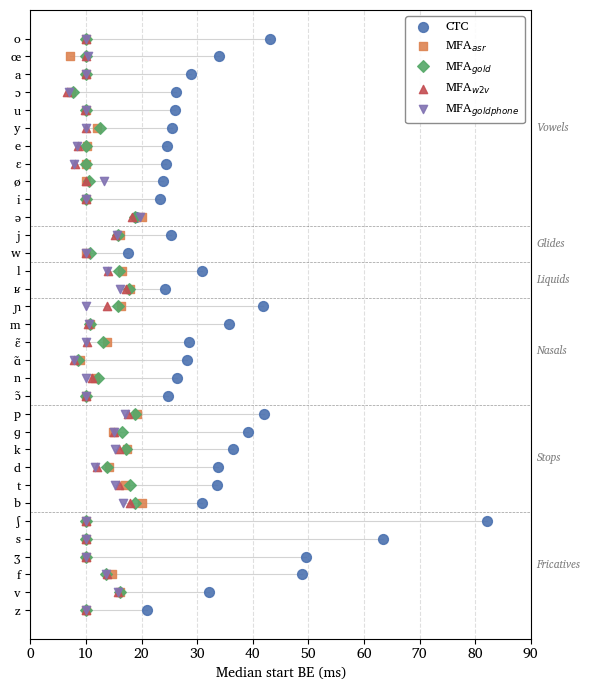

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# Use a font with full IPA support
# fallback if not available:
# rcParams['font.family'] = 'Noto Sans'
# or: rcParams['font.family'] = 'Charis SIL'

rcParams['font.family'] = 'Charis SIL'

# Sort within each category by CTC error (ascending)
categories = {
    "Fricatives": ["z", "v", "f", "ʒ", "ʃ", "s"],
    "Stops":      ["b", "d", "ɡ", "p", "t", "k"],
    "Nasals":     ["ɔ̃", "ɑ̃", "ɛ̃", "ɲ", "n", "m"],
    "Liquids":    ["ʁ", "l"],
    "Glides":     ["w", "j"],
    "Vowels":     ["ə", "œ", "ø", "ɔ", "o", "u", "y", "ɛ", "e", "a", "i"],
}

# Use only 3 systems for clarity
systems_plot = ["CTC", "MFA_asrw2v", "MFA_gold", "MFA_w2v", "MFA_goldphone"]
labels       = ["CTC", "MFA$_{asr}$", "MFA$_{gold}$", "MFA$_{w2v}$", "MFA$_{goldphone}$"]
colors       = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
markers      = ["o", "s", "D", "^", "v"]
sizes        = [50, 35, 35, 35, 35]

ordered_phonemes = []
category_boundaries = []
category_label_pos = {}

pos = 0
for cat, phones in categories.items():
    phones = [p for p in phones if p in pivot.index]
    # sort within category by CTC ascending
    phones = sorted(phones, key=lambda p: pivot.loc[p, "CTC"])
    category_label_pos[cat] = pos + len(phones) / 2 - 0.5
    for ph in phones:
        ordered_phonemes.append(ph)
        pos += 1
    category_boundaries.append(pos - 0.5)

category_boundaries = category_boundaries[:-1]
y = np.arange(len(ordered_phonemes))
pivot_ordered = pivot.loc[ordered_phonemes]

fig, ax = plt.subplots(figsize=(6, 7))

# Gray line from MFA_w2v to CTC
mfa_cols = ["MFA_asrw2v", "MFA_gold", "MFA_w2v", "MFA_goldphone"]
for yi, ph in zip(y, ordered_phonemes):
    mfa_min = pivot_ordered.loc[ph, mfa_cols].min()
    ctc_val = pivot_ordered.loc[ph, "CTC"]
    ax.plot([mfa_min, ctc_val], [yi, yi],
            color="lightgray", linewidth=0.8, zorder=1)


# Plot systems
for sys, lbl, col, mk, sz in zip(systems_plot, labels, colors, markers, sizes):
    ax.scatter(pivot_ordered[sys], y,
               color=col, marker=mk, s=sz,
               label=lbl, zorder=3, alpha=0.9)

# Category separators
for yb in category_boundaries:
    ax.axhline(y=yb, color="black", linewidth=0.5,
               linestyle="--", alpha=0.4)

# Category labels inside plot on right
# Replace the category labels block with this:
for cat, yc in category_label_pos.items():
    ax.text(91, yc, cat, fontsize=8, va="center", ha="left",
            color="gray", style="italic",
            clip_on=False)

ax.set_yticks(y)
ax.set_yticklabels(ordered_phonemes, fontsize=9)
ax.set_xlabel("Median start BE (ms)", fontsize=10)
ax.set_xlim(0, 90)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc="upper right", ncol=1,
          framealpha=0.9, edgecolor="gray")

plt.tight_layout()
plt.savefig("phoneme_errors_dot_v3.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
systems_info = {
    "CTC":           "ctc_results",
    "MFA_asrw2v":    "mfa_results_asrw2v",
    "MFA_gold":      "mfa_results_gold",
    "MFA_w2v":       "mfa_results_w2vmfa",
    "MFA_goldphone": "mfa_results_goldphone",
}

dataset_files = {
    "Rhapsodie_Planned": ("alignment_rhap.pkl", "planned"),
    "Rhapsodie_Semi":    ("alignment_rhap.pkl", "semi"),
    "Rhapsodie_Spont":   ("alignment_rhap.pkl", "spont"),
    "Typaloc_Ctrl":      ("alignment_ctrl.pkl",  None),
    "Typaloc_Park":      ("alignment_park.pkl",  None),
    "Typaloc_Cereb":     ("alignment_cereb.pkl", None),
    "Typaloc_Sla":       ("alignment_sla.pkl",   None),
    "Tapas":             ("alignment_tapas.pkl",          None),
}

def compute_phoneme_errors(store, system_name, dataset_name, style_filter=None):
    records = []
    for fname, data in store.items():
        if style_filter is not None:
            if data.get("style", "").lower() != style_filter.lower():
                continue
        _, _, _, mid_err, matched_pairs, _ = match_alignments_lev(
            data["ref_intervals"], data["hyp_intervals"],
            data["ref_seq"], data["hyp_seq"])
        for (ri, hi), merr in zip(matched_pairs, mid_err):
            r = data["ref_intervals"][ri]
            h = data["hyp_intervals"][hi]
            start_err = abs(r["start"] - h["start"]) * 1000
            dur       = (r["end"] - r["start"]) * 1000
            records.append({
                "system":    system_name,
                "dataset":   dataset_name,
                "file":      fname,
                "style":     data.get("style", "?"),
                "phoneme":   data["ref_seq"][ri],
                "start_err": start_err,
                "duration":  dur,
            })
    return pd.DataFrame(records)

all_dfs = []
for sys_label, sys_folder in systems_info.items():
    for dataset_name, (pkl_file, style_filter) in dataset_files.items():
        path = f"{sys_folder}/{pkl_file}"
        with open(path, "rb") as f:
            store = pickle.load(f)
        df_tmp = compute_phoneme_errors(store, sys_label, dataset_name, style_filter)
        all_dfs.append(df_tmp)
        print(f"  {sys_label} {dataset_name}: {len(df_tmp)} rows")

df_ph = pd.concat(all_dfs, ignore_index=True)
print(f"\ndf_ph shape: {df_ph.shape}")
print(f"columns: {df_ph.columns.tolist()}")
print(df_ph["dataset"].value_counts())

  CTC Rhapsodie_Planned: 26192 rows
  CTC Rhapsodie_Semi: 11960 rows
  CTC Rhapsodie_Spont: 37703 rows
  CTC Typaloc_Ctrl: 5769 rows
  CTC Typaloc_Park: 3610 rows
  CTC Typaloc_Cereb: 3573 rows
  CTC Typaloc_Sla: 4183 rows
  CTC Tapas: 26171 rows
  MFA_asrw2v Rhapsodie_Planned: 20963 rows
  MFA_asrw2v Rhapsodie_Semi: 9847 rows
  MFA_asrw2v Rhapsodie_Spont: 28161 rows
  MFA_asrw2v Typaloc_Ctrl: 4600 rows
  MFA_asrw2v Typaloc_Park: 2692 rows
  MFA_asrw2v Typaloc_Cereb: 2325 rows
  MFA_asrw2v Typaloc_Sla: 2830 rows
  MFA_asrw2v Tapas: 22812 rows
  MFA_gold Rhapsodie_Planned: 23062 rows
  MFA_gold Rhapsodie_Semi: 12212 rows
  MFA_gold Rhapsodie_Spont: 37680 rows
  MFA_gold Typaloc_Ctrl: 5016 rows
  MFA_gold Typaloc_Park: 3305 rows
  MFA_gold Typaloc_Cereb: 2835 rows
  MFA_gold Typaloc_Sla: 4593 rows
  MFA_gold Tapas: 26234 rows
  MFA_w2v Rhapsodie_Planned: 26192 rows
  MFA_w2v Rhapsodie_Semi: 11960 rows
  MFA_w2v Rhapsodie_Spont: 37703 rows
  MFA_w2v Typaloc_Ctrl: 5769 rows
  MFA_w2v Typal

In [23]:
# Rebuild df_ph using only Typaloc
typaloc_datasets = ["Typaloc_Ctrl", "Typaloc_Park", "Typaloc_Cereb", "Typaloc_Sla"]

# Filter df_ph
df_ph_typaloc = df_ph[df_ph["dataset"].isin(typaloc_datasets)]

# Compute global pivot over all Typaloc data combined
summary_typaloc = (df_ph_typaloc
    .groupby(["system", "phoneme"])
    .agg(median_be=("start_err", "median"),
         n=("start_err", "count"))
    .reset_index()
)
summary_typaloc = summary_typaloc[summary_typaloc["n"] >= 30]
pivot_typaloc = summary_typaloc.pivot(
    index="phoneme", columns="system", values="median_be")
pivot_typaloc = pivot_typaloc.dropna()

print(f"Typaloc phonemes: {len(pivot_typaloc)}")
print(pivot_typaloc.sort_values("CTC", ascending=False).to_string())

Typaloc phonemes: 31
system         CTC  MFA_asrw2v   MFA_gold  MFA_goldphone    MFA_w2v
phoneme                                                            
ʃ        92.008457   10.891616  12.456536      10.695179  10.891616
f        87.630382   13.634794  16.865532      13.344588  12.522917
s        86.944382   10.001000  10.531561      10.000000  10.001000
b        75.473622   16.795007  17.569847      10.000000  17.330660
k        75.174091   13.596184  15.787690      11.717901  14.410731
p        74.624977   11.108751  11.831174      11.029090  11.352761
t        68.311734   19.999000  22.336376      20.000000  20.000000
ɡ        64.236453   10.000500  10.001000      10.002000  10.001000
m        62.518112   10.112034  10.811336      10.000000  10.000000
d        58.285714   10.002000  10.002000      10.000000  10.000000
ʒ        52.173907   10.277682  10.937524      10.451207  10.001000
n        48.913156   15.917112  15.617333      10.396349  13.423051
v        47.090909   11.834

Typaloc_Ctrl: 31 phonemes
Typaloc_Park: 30 phonemes
Typaloc_Cereb: 30 phonemes
Typaloc_Sla: 31 phonemes

Common phonemes: 30: ['z', 'v', 'ʒ', 'f', 's', 'ʃ', 'd', 'ɡ', 't', 'b', 'p', 'k', 'ɛ̃', 'ɔ̃', 'ɑ̃', 'n', 'm', 'ʁ', 'l', 'w', 'j', 'i', 'ø', 'u', 'e', 'ɛ', 'y', 'a', 'ɔ', 'o']

CTC matrix: (4, 30), non-nan: 120
MFA matrix: (4, 30), non-nan: 120
Rec vector: non-nan: 30
CTC global max: 130.2ms
MFA global max: 67.3ms
CTC norm for Ctrl (first row):
[0.16026896 0.33161947 0.35210237 0.6369801  0.57617197 0.66290982
 0.38106369 0.42678697 0.45413848 0.49363436 0.48644798 0.55371894
 0.18843505 0.17453051 0.19963219 0.33181891 0.39717746 0.24090774
 0.28900849 0.13033564 0.28063512 0.16523403 0.16837111 0.11686477
 0.18505748 0.21380829 0.22742272 0.25331232 0.23693753 0.27966223]
Max CTC BE for Ctrl: 86.3ms
CTC norm for z (first phoneme):
[0.16026896 0.11812556 0.27533939 0.34546995]
Max BE for z: 45.0ms

Full matrix shape: (9, 30)
Non-nan cells: 270


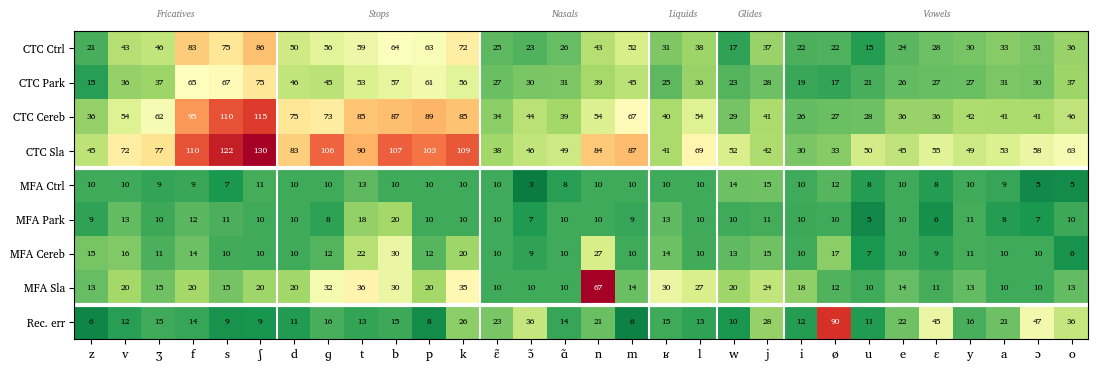

In [33]:
from matplotlib import rcParams
rcParams['font.family'] = 'Charis SIL'

MIN_SAMPLES = 10

# ── Step 1: Build pivots_typaloc ──────────────────────────────────────────────
pivots_typaloc = {}
for dataset_name in typaloc_datasets:
    df_sub = df_ph[
        (df_ph["dataset"] == dataset_name) &
        (df_ph["system"].isin(["CTC", "MFA_w2v"]))
    ]
    summary_ds = (df_sub
        .groupby(["system", "phoneme"])
        .agg(median_be=("start_err", "median"),
             n=("start_err", "count"))
        .reset_index()
    )
    summary_ds = summary_ds[summary_ds["n"] >= MIN_SAMPLES]
    pivot_ds = summary_ds.pivot(
        index="phoneme", columns="system", values="median_be")
    pivot_ds = pivot_ds.dropna()
    pivots_typaloc[dataset_name] = pivot_ds
    print(f"{dataset_name}: {len(pivot_ds)} phonemes")

# ── Step 2: Build common phoneme list ─────────────────────────────────────────
common_ph_typaloc = set.intersection(*[
    set(pivots_typaloc[ds].index) for ds in typaloc_datasets
])

ordered_ph_opt_a = []
cat_boundaries_a = []
cat_label_pos_a  = {}
pos = 0

for cat, phones in categories.items():
    phones_in = [p for p in phones if p in common_ph_typaloc]
    if not phones_in:
        continue
    phones_in = sorted(phones_in, key=lambda p: np.nanmean([
        pivots_typaloc[ds].loc[p, "CTC"]
        if p in pivots_typaloc[ds].index and "CTC" in pivots_typaloc[ds].columns
        else np.nan
        for ds in typaloc_datasets
    ]))
    cat_label_pos_a[cat] = pos + len(phones_in) / 2 - 0.5
    for ph in phones_in:
        ordered_ph_opt_a.append(ph)
        pos += 1
    cat_boundaries_a.append(pos - 0.5)

cat_boundaries_a = cat_boundaries_a[:-1]
ph_common = ordered_ph_opt_a  # no extra filtering needed
print(f"\nCommon phonemes: {len(ph_common)}: {ph_common}")

# ── Step 3: Build raw matrices ────────────────────────────────────────────────
n_ph   = len(ph_common)
n_cond = len(typaloc_datasets)

ctc_matrix = np.full((n_cond, n_ph), np.nan)
mfa_matrix = np.full((n_cond, n_ph), np.nan)
rec_vector = np.full(n_ph, np.nan)

for i, dataset_name in enumerate(typaloc_datasets):
    pivot_ds = pivots_typaloc[dataset_name]
    for j, ph in enumerate(ph_common):
        if ph in pivot_ds.index:
            if "CTC" in pivot_ds.columns:
                ctc_matrix[i, j] = min(pivot_ds.loc[ph, "CTC"], 150)
            if "MFA_w2v" in pivot_ds.columns:
                mfa_matrix[i, j] = min(pivot_ds.loc[ph, "MFA_w2v"], 150)

# Recognition error
df_rec_typaloc = df_rec[
    (df_rec["system"] == "CTC") &
    (df_rec["dataset"].isin(typaloc_datasets))
]
rec_typaloc = (df_rec_typaloc
    .groupby("phoneme")
    .apply(lambda x: pd.Series({
        "error_rate": (x["operation"] != "correct").sum() / len(x) * 100,
        "n": len(x)
    }))
    .reset_index()
)
rec_typaloc = rec_typaloc[rec_typaloc["n"] >= MIN_SAMPLES].set_index("phoneme")
for j, ph in enumerate(ph_common):
    if ph in rec_typaloc.index:
        rec_vector[j] = rec_typaloc.loc[ph, "error_rate"]

print(f"\nCTC matrix: {ctc_matrix.shape}, non-nan: {np.sum(~np.isnan(ctc_matrix))}")
print(f"MFA matrix: {mfa_matrix.shape}, non-nan: {np.sum(~np.isnan(mfa_matrix))}")
print(f"Rec vector: non-nan: {np.sum(~np.isnan(rec_vector))}")

# ── Step 4: Normalize per phoneme across conditions ───────────────────────────
# Normalize each row by its max value
# Normalize CTC matrix by its global max across all conditions and phonemes
ctc_global_max = np.nanmax(ctc_matrix)
ctc_norm = ctc_matrix / ctc_global_max

# Normalize MFA matrix by its global max across all conditions and phonemes
mfa_global_max = np.nanmax(mfa_matrix)
mfa_norm = mfa_matrix / mfa_global_max

# Recognition: fixed 0-100 range
rec_norm = rec_vector / 100.0

# Stack
full_matrix      = np.vstack([ctc_matrix, mfa_matrix, rec_vector.reshape(1, -1)])
full_matrix_norm = np.vstack([ctc_norm,   mfa_norm,   rec_norm.reshape(1, -1)])

print(f"CTC global max: {ctc_global_max:.1f}ms")
print(f"MFA global max: {mfa_global_max:.1f}ms")
print("CTC norm for Ctrl (first row):")
print(ctc_norm[0, :])
print(f"Max CTC BE for Ctrl: {np.nanmax(ctc_matrix[0, :]):.1f}ms")
print("CTC norm for z (first phoneme):")
print(ctc_norm[:, 0])
print(f"Max BE for z: {np.nanmax(np.concatenate([ctc_matrix[:, 0], mfa_matrix[:, 0]])):.1f}ms")

# Recognition: fixed 0-100 range
rec_norm = rec_vector / 100.0

# Stack
full_matrix      = np.vstack([ctc_matrix, mfa_matrix, rec_vector.reshape(1, -1)])
full_matrix_norm = np.vstack([ctc_norm,   mfa_norm,   rec_norm.reshape(1, -1)])

print(f"\nFull matrix shape: {full_matrix.shape}")
print(f"Non-nan cells: {np.sum(~np.isnan(full_matrix))}")

fig, ax = plt.subplots(figsize=(13, 4))

im = ax.imshow(full_matrix_norm, aspect="auto", cmap="RdYlGn_r",
               vmin=0, vmax=1, interpolation="none",
               origin="upper")  # row 0 at top

# Annotate with actual values
for i in range(9):
    for j in range(n_ph):
        if not np.isnan(full_matrix[i, j]):
            ax.text(j, i, f"{full_matrix[i,j]:.0f}",
                    ha="center", va="center", fontsize=6,
                    color="white" if full_matrix_norm[i,j] > 0.7 else "black")

# Horizontal separators
ax.axhline(y=3.5, color="white", linewidth=3)
ax.axhline(y=7.5, color="white", linewidth=3)

# Category vertical separators
cat_x_boundaries = []
cat_x_labels = {}
pos = 0
for cat, phones in categories.items():
    phones_in = [p for p in phones if p in ph_common]
    if not phones_in:
        continue
    cat_x_labels[cat] = pos + len(phones_in) / 2 - 0.5
    pos += len(phones_in)
    cat_x_boundaries.append(pos - 0.5)
cat_x_boundaries = cat_x_boundaries[:-1]

for xb in cat_x_boundaries:
    ax.axvline(x=xb, color="white", linewidth=1.5)

# Category labels on top
for cat, xc in cat_x_labels.items():
    x_frac = (xc + 0.5) / n_ph
    ax.annotate(cat, xy=(x_frac, 1.04),
                xycoords="axes fraction",
                fontsize=7, ha="center", va="bottom",
                color="gray", style="italic",
                annotation_clip=False)

# Y axis labels
y_labels = ["CTC Ctrl", "CTC Park", "CTC Cereb", "CTC Sla",
            "MFA Ctrl", "MFA Park", "MFA Cereb", "MFA Sla",
            "Rec. err"]
ax.set_yticks(range(9))
ax.set_yticklabels(y_labels, fontsize=8)

# Block labels on left


# X axis labels
ax.set_xticks(range(n_ph))
ax.set_xticklabels(ph_common, fontsize=9, fontfamily="Charis SIL")



plt.subplots_adjust(right=0.9, left=0.12)
plt.savefig("typaloc_phoneme_normalized.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
for dataset_name in typaloc_datasets:
    df_sub = df_rec[
        (df_rec["system"] == "CTC") &
        (df_rec["dataset"] == dataset_name)
    ]
    rec_ds = (df_sub
        .groupby("phoneme")
        .apply(lambda x: (x["operation"] != "correct").sum() / len(x) * 100)
    )
    print(f"\n{dataset_name}:")
    print(rec_ds.sort_values(ascending=False).head(5).round(1))


Typaloc_Ctrl:
phoneme
ɥ    100.0
ø     87.4
ɛ     40.0
ɔ     39.2
o     30.1
dtype: float64

Typaloc_Park:
phoneme
ɥ     100.0
ø      89.6
ɛ      46.6
ɔ      42.7
ɔ̃     39.3
dtype: float64

Typaloc_Cereb:
phoneme
ɥ    100.0
ə    100.0
ø     89.4
œ     52.9
ɛ     43.8
dtype: float64

Typaloc_Sla:
phoneme
ɥ    100.0
ø     91.7
œ     72.4
ɔ     63.9
ɛ     49.0
dtype: float64


In [29]:
print("CTC norm for z (first phoneme):")
print(ctc_norm[:, 0])  # should be [~0.2, 0.0, ~0.6, 1.0]

print("\nFull matrix norm first column:")
print(full_matrix_norm[:, 0])

CTC norm for z (first phoneme):
[0.18537249 0.         0.69152282 1.        ]

Full matrix norm first column:
[0.18537249 0.         0.69152282 1.         0.16941835 0.
 1.         0.70098535 0.06282723]


In [9]:
fig, ax = plt.subplots(figsize=(12, 3))

# Build difference matrix: 4 conditions × n phonemes
diff_matrix = np.full((4, len(ordered_ph)), np.nan)

for i, dataset_name in enumerate(typaloc_datasets):
    pivot_ds = pivots_typaloc[dataset_name]
    for j, ph in enumerate(ordered_ph):
        if ph in pivot_ds.index:
            ctc = pivot_ds.loc[ph, "CTC"] if "CTC" in pivot_ds.columns else np.nan
            mfa = pivot_ds.loc[ph, "MFA_w2v"] if "MFA_w2v" in pivot_ds.columns else np.nan
            if not np.isnan(ctc) and not np.isnan(mfa):
                diff_matrix[i, j] = ctc - mfa  # positive = CTC worse than MFA

im = ax.imshow(diff_matrix, aspect="auto", cmap="RdYlGn_r",
               vmin=0, vmax=100, interpolation="none")

# Annotate
for i in range(4):
    for j in range(len(ordered_ph)):
        if not np.isnan(diff_matrix[i, j]):
            ax.text(j, i, f"{diff_matrix[i,j]:.0f}",
                    ha="center", va="center", fontsize=6.5,
                    color="white" if diff_matrix[i,j] > 70 else "black")

# Category separators
cat_x_boundaries = []
cat_x_labels = {}
pos = 0
for cat, phones in categories.items():
    phones_in = [p for p in phones if p in ordered_ph]
    if not phones_in:
        continue
    cat_x_labels[cat] = pos + len(phones_in) / 2 - 0.5
    pos += len(phones_in)
    cat_x_boundaries.append(pos - 0.5)
cat_x_boundaries = cat_x_boundaries[:-1]

for xb in cat_x_boundaries:
    ax.axvline(x=xb, color="white", linewidth=1.5)

# Category labels on top
for cat, xc in cat_x_labels.items():
    x_frac = (xc + 0.5) / len(ordered_ph)
    ax.annotate(cat, xy=(x_frac, 1.02),
                xycoords="axes fraction",
                fontsize=7, ha="center", va="bottom",
                color="gray", style="italic",
                annotation_clip=False)

ax.set_yticks(range(4))
ax.set_yticklabels(["Ctrl", "Park", "Cereb", "Sla"], fontsize=9)
ax.set_xticks(range(len(ordered_ph)))
ax.set_xticklabels(ordered_ph, fontsize=9, fontfamily="Charis SIL")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("CTC BE − MFA$_{w2v}$ BE (ms)", fontsize=8)
cbar.ax.tick_params(labelsize=7)

ax.set_title("CTC vs MFA$_{w2v}$ alignment gap per phoneme and condition",
             fontsize=10)

plt.tight_layout()
plt.savefig("diff_heatmap_compact.pdf", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

In [10]:
from matplotlib import rcParams
rcParams['font.family'] = 'Charis SIL'

# ── Build data ────────────────────────────────────────────────────────────────

df_ph_typaloc = df_ph[df_ph["dataset"].isin(typaloc_datasets)]

summary_typaloc = (df_ph_typaloc[df_ph_typaloc["system"].isin(["CTC", "MFA_w2v"])]
    .groupby(["system", "phoneme"])
    .agg(median_be=("start_err", "median"),
         n=("start_err", "count"))
    .reset_index()
)
summary_typaloc = summary_typaloc[summary_typaloc["n"] >= 30]
pivot_typaloc = summary_typaloc.pivot(
    index="phoneme", columns="system", values="median_be")
pivot_typaloc = pivot_typaloc.dropna()

# Build ordered phoneme list by category, sorted by CTC BE descending
ordered_ph_opt_a = []
cat_boundaries_a = []
cat_label_pos_a  = {}
pos = 0

for cat, phones in categories.items():
    phones_in = [p for p in phones if p in pivot_typaloc.index]
    if not phones_in:
        continue
    phones_in = sorted(phones_in,
                       key=lambda p: pivot_typaloc.loc[p, "CTC"],
                       ascending=False) if False else \
                sorted(phones_in,
                       key=lambda p: pivot_typaloc.loc[p, "CTC"])
    cat_label_pos_a[cat] = pos + len(phones_in) / 2 - 0.5
    for ph in phones_in:
        ordered_ph_opt_a.append(ph)
        pos += 1
    cat_boundaries_a.append(pos - 0.5)

cat_boundaries_a = cat_boundaries_a[:-1]
y_a = np.arange(len(ordered_ph_opt_a))
pivot_ordered_a = pivot_typaloc.loc[ordered_ph_opt_a]

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, len(ordered_ph_opt_a) * 0.30))

# Gray line from MFA to CTC
for yi, ph in zip(y_a, ordered_ph_opt_a):
    ctc_val = pivot_ordered_a.loc[ph, "CTC"]
    mfa_val = pivot_ordered_a.loc[ph, "MFA_w2v"]
    ax.plot([mfa_val, ctc_val], [yi, yi],
            color="lightgray", linewidth=0.8, zorder=1)

# CTC dots
ax.scatter(pivot_ordered_a["CTC"], y_a,
           color="#4C72B0", marker="o", s=55,
           label="CTC", zorder=3, alpha=0.9)

# MFA_w2v dots
ax.scatter(pivot_ordered_a["MFA_w2v"], y_a,
           color="#DD8452", marker="^", s=45,
           label="MFA$_{w2v}$", zorder=3, alpha=0.9)

# Category separators
for yb in cat_boundaries_a:
    ax.axhline(y=yb, color="black", linewidth=0.5,
               linestyle="--", alpha=0.4)

# Category labels on right
for cat, yc in cat_label_pos_a.items():
    ax.text(ax.get_xlim()[1] * 1.02 if ax.get_xlim()[1] > 0 else 155,
            yc, cat, fontsize=7, va="center", ha="left",
            color="gray", style="italic", clip_on=False)

ax.set_yticks(y_a)
ax.set_yticklabels(ordered_ph_opt_a, fontsize=9, fontfamily="Charis SIL")
ax.set_xlabel("Median start BE (ms)", fontsize=10)
ax.set_xlim(0, 150)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=9, loc="lower right", framealpha=0.9)

# Annotate gap for top fricatives

plt.tight_layout()
plt.savefig("ctc_vs_mfa_gap_typaloc.pdf", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'categories' is not defined

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, len(ordered_ph_opt_a) * 0.30),
                                sharey=True,
                                gridspec_kw={"width_ratios": [2, 1]})

# ── Left panel: alignment dot plot ───────────────────────────────────────────

for yi, ph in zip(y_a, ordered_ph_opt_a):
    ctc_val = pivot_ordered_a.loc[ph, "CTC"]
    mfa_val = pivot_ordered_a.loc[ph, "MFA_w2v"]
    ax1.plot([mfa_val, ctc_val], [yi, yi],
             color="lightgray", linewidth=0.8, zorder=1)

ax1.scatter(pivot_ordered_a["CTC"], y_a,
            color="#4C72B0", marker="o", s=55,
            label="CTC", zorder=3, alpha=0.9)
ax1.scatter(pivot_ordered_a["MFA_w2v"], y_a,
            color="#DD8452", marker="^", s=45,
            label="MFA$_{w2v}$", zorder=3, alpha=0.9)

for yb in cat_boundaries_a:
    ax1.axhline(y=yb, color="black", linewidth=0.5,
                linestyle="--", alpha=0.4)

ax1.set_yticks(y_a)
ax1.set_yticklabels(ordered_ph_opt_a, fontsize=9, fontfamily="Charis SIL")
ax1.set_xlabel("Median start BE (ms)", fontsize=10)
ax1.set_xlim(0, 150)
ax1.xaxis.grid(True, linestyle="--", alpha=0.4)
ax1.set_axisbelow(True)
ax1.legend(fontsize=8, loc="lower right", framealpha=0.9)
ax1.set_title("Alignment", fontsize=10, fontweight="bold")

# Annotate gap for top fricatives
for ph in ["ʃ", "s", "ʒ", "f"]:
    if ph in pivot_ordered_a.index:
        yi = ordered_ph_opt_a.index(ph)
        ctc = pivot_ordered_a.loc[ph, "CTC"]
        mfa = pivot_ordered_a.loc[ph, "MFA_w2v"]
        ax1.annotate(f"Δ{ctc-mfa:.0f}ms",
                     xy=(ctc, yi),
                     xytext=(5, 0), textcoords="offset points",
                     fontsize=6.5, color="#4C72B0", va="center")

# ── Right panel: recognition error bar chart ─────────────────────────────────

# Build recognition error per phoneme from Typaloc
df_rec_typaloc = df_rec[
    (df_rec["system"] == "CTC") &
    (df_rec["dataset"].isin(typaloc_datasets))
]
rec_typaloc = (df_rec_typaloc
    .groupby("phoneme")
    .apply(lambda x: pd.Series({
        "error_rate": (x["operation"] != "correct").sum() / len(x) * 100,
        "del_rate":   (x["operation"] == "deletion").sum() / len(x) * 100,
        "sub_rate":   (x["operation"] == "substitution").sum() / len(x) * 100,
        "n": len(x)
    }))
    .reset_index()
)
rec_typaloc = rec_typaloc[rec_typaloc["n"] >= 30].set_index("phoneme")

# Horizontal stacked bar: deletion + substitution
del_rates = [rec_typaloc.loc[ph, "del_rate"]
             if ph in rec_typaloc.index else 0
             for ph in ordered_ph_opt_a]
sub_rates = [rec_typaloc.loc[ph, "sub_rate"]
             if ph in rec_typaloc.index else 0
             for ph in ordered_ph_opt_a]

ax2.barh(y_a, del_rates, height=0.6,
         color="#55A868", alpha=0.85, label="Deletion")
ax2.barh(y_a, sub_rates, height=0.6,
         left=del_rates, color="#C44E52", alpha=0.85, label="Substitution")

for yb in cat_boundaries_a:
    ax2.axhline(y=yb, color="black", linewidth=0.5,
                linestyle="--", alpha=0.4)

# Category labels on right side
for cat, yc in cat_label_pos_a.items():
    ax2.text(102, yc, cat, fontsize=7, va="center", ha="left",
             color="gray", style="italic", clip_on=False)

ax2.set_xlabel("Recognition\nerror rate (%)", fontsize=9)
ax2.set_xlim(0, 100)
ax2.xaxis.grid(True, linestyle="--", alpha=0.4)
ax2.set_axisbelow(True)
ax2.legend(fontsize=7, loc="lower right", framealpha=0.9)
ax2.set_title("Recognition", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("ctc_vs_mfa_with_recognition.pdf", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

In [12]:
from matplotlib import rcParams
rcParams['font.family'] = 'Charis SIL'

# ── Build raw matrices ────────────────────────────────────────────────────────

# Common phonemes across all 4 Typaloc conditions for CTC and MFA_w2v
ph_common = [p for p in ordered_ph_opt_a if p in pivot_typaloc.index]

n_ph   = len(ph_common)
n_cond = len(typaloc_datasets)

# Raw matrices: conditions × phonemes
ctc_matrix = np.full((n_cond, n_ph), np.nan)
mfa_matrix = np.full((n_cond, n_ph), np.nan)
rec_vector = np.full(n_ph, np.nan)  # recognition is condition-independent

for i, dataset_name in enumerate(typaloc_datasets):
    pivot_ds = pivots_typaloc[dataset_name]
    for j, ph in enumerate(ph_common):
        if ph in pivot_ds.index:
            if "CTC" in pivot_ds.columns:
                ctc_matrix[i, j] = min(pivot_ds.loc[ph, "CTC"], 150)
            if "MFA_w2v" in pivot_ds.columns:
                mfa_matrix[i, j] = min(pivot_ds.loc[ph, "MFA_w2v"], 150)

# Recognition error — Typaloc combined
df_rec_typaloc = df_rec[
    (df_rec["system"] == "CTC") &
    (df_rec["dataset"].isin(typaloc_datasets))
]
rec_typaloc = (df_rec_typaloc
    .groupby("phoneme")
    .apply(lambda x: pd.Series({
        "error_rate": (x["operation"] != "correct").sum() / len(x) * 100,
        "n": len(x)
    }))
    .reset_index()
)
rec_typaloc = rec_typaloc[rec_typaloc["n"] >= 30].set_index("phoneme")
for j, ph in enumerate(ph_common):
    if ph in rec_typaloc.index:
        rec_vector[j] = rec_typaloc.loc[ph, "error_rate"]

# ── Normalize per phoneme across all conditions ───────────────────────────────
# For each phoneme j, normalize CTC and MFA values across the 4 conditions
# so color shows: which condition is hardest for THIS phoneme

ctc_norm = np.full_like(ctc_matrix, np.nan)
mfa_norm = np.full_like(mfa_matrix, np.nan)

for j in range(n_ph):
    # CTC: normalize across 4 conditions for this phoneme
    col = ctc_matrix[:, j]
    col_min, col_max = np.nanmin(col), np.nanmax(col)
    if col_max > col_min:
        ctc_norm[:, j] = (col - col_min) / (col_max - col_min)
    else:
        ctc_norm[:, j] = 0.0

    # MFA: normalize across 4 conditions for this phoneme
    col = mfa_matrix[:, j]
    col_min, col_max = np.nanmin(col), np.nanmax(col)
    if col_max > col_min:
        mfa_norm[:, j] = (col - col_min) / (col_max - col_min)
    else:
        mfa_norm[:, j] = 0.0

# Recognition: fixed 0-100 range (absolute)
rec_norm = rec_vector / 100.0

# ── Stack into full matrix ────────────────────────────────────────────────────
# Layout: 4 CTC rows + separator + 4 MFA rows + separator + 1 rec row = 9 rows
full_matrix      = np.vstack([ctc_matrix, mfa_matrix, rec_vector.reshape(1, -1)])
full_matrix_norm = np.vstack([ctc_norm,   mfa_norm,   rec_norm.reshape(1, -1)])

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 4))

im = ax.imshow(full_matrix_norm, aspect="auto", cmap="RdYlGn_r",
               vmin=0, vmax=1, interpolation="none")

# Annotate with actual values
for i in range(9):
    for j in range(n_ph):
        if not np.isnan(full_matrix[i, j]):
            ax.text(j, i, f"{full_matrix[i,j]:.0f}",
                    ha="center", va="center", fontsize=6,
                    color="white" if full_matrix_norm[i,j] > 0.7 else "black")

# Horizontal separators
ax.axhline(y=3.5, color="white", linewidth=3)  # between CTC and MFA blocks
ax.axhline(y=7.5, color="white", linewidth=3)  # between MFA and Rec blocks

# Category vertical separators
cat_x_boundaries = []
cat_x_labels = {}
pos = 0
for cat, phones in categories.items():
    phones_in = [p for p in phones if p in ph_common]
    if not phones_in:
        continue
    cat_x_labels[cat] = pos + len(phones_in) / 2 - 0.5
    pos += len(phones_in)
    cat_x_boundaries.append(pos - 0.5)
cat_x_boundaries = cat_x_boundaries[:-1]

for xb in cat_x_boundaries:
    ax.axvline(x=xb, color="white", linewidth=1.5)

# Category labels on top
for cat, xc in cat_x_labels.items():
    x_frac = (xc + 0.5) / n_ph
    ax.annotate(cat, xy=(x_frac, 1.04),
                xycoords="axes fraction",
                fontsize=7, ha="center", va="bottom",
                color="gray", style="italic",
                annotation_clip=False)

# Y axis labels
y_labels = ["CTC Ctrl", "CTC Park", "CTC Cereb", "CTC Sla",
            "MFA Ctrl", "MFA Park", "MFA Cereb", "MFA Sla",
            "Rec. err"]
ax.set_yticks(range(9))
ax.set_yticklabels(y_labels, fontsize=8)

# Block labels on left
ax.text(-0.08, 1.5/9, "CTC\nBE", fontsize=8, fontweight="bold",
        ha="center", va="center", transform=ax.transAxes,
        color="#4C72B0")
ax.text(-0.08, 5.5/9, "MFA\nBE", fontsize=8, fontweight="bold",
        ha="center", va="center", transform=ax.transAxes,
        color="#DD8452")
ax.text(-0.08, 8.5/9, "Rec\nerr", fontsize=8, fontweight="bold",
        ha="center", va="center", transform=ax.transAxes,
        color="#55A868")

# X axis labels
ax.set_xticks(range(n_ph))
ax.set_xticklabels(ph_common, fontsize=9, fontfamily="Charis SIL")

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.012, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Normalized per phoneme\n(0=best condition, 1=worst condition)",
               fontsize=7)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Best", "Mid", "Worst"])
cbar.ax.tick_params(labelsize=6)

plt.subplots_adjust(right=0.9, left=0.12)
plt.savefig("typaloc_phoneme_normalized.pdf", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'pivots_typaloc' is not defined

In [14]:
def compute_phoneme_errors(store, system_name, dataset_name):
    records = []
    for fname, data in store.items():
        _, _, _, mid_err, matched_pairs, _ = match_alignments_lev(
            data["ref_intervals"], data["hyp_intervals"],
            data["ref_seq"], data["hyp_seq"])
        
        for (ri, hi), merr in zip(matched_pairs, mid_err):
            r = data["ref_intervals"][ri]
            h = data["hyp_intervals"][hi]
            start_err = abs(r["start"] - h["start"]) * 1000
            dur       = (r["end"] - r["start"]) * 1000
            
            records.append({
                "system":   system_name,
                "dataset":  dataset_name,
                "file":     fname,
                "style":    data.get("style", "?"),
                "phoneme":  data["ref_seq"][ri],
                "start_err": start_err,
                "duration": dur,
            })
    return pd.DataFrame(records)

In [13]:
systems_info = {
    "CTC":           "ctc_results",
    "MFA_asrw2v":    "mfa_results_asrw2v",
    "MFA_gold":      "mfa_results_gold",
    "MFA_w2v":       "mfa_results_w2vmfa",
    "MFA_goldphone": "mfa_results_goldphone",
}

dataset_files = {
    "Rhapsodie": ["alignment_rhap.pkl"],
    "Typaloc_Ctrl":  ["alignment_ctrl.pkl"],
    "Typaloc_Park":  ["alignment_park.pkl"],
    "Typaloc_Cereb": ["alignment_cereb.pkl"],
    "Typaloc_Sla":   ["alignment_sla.pkl"],
    "Tapas":         ["alignment_tapas.pkl"],
}

all_dfs = []
for sys_label, sys_folder in systems_info.items():
    for dataset_name, pkl_files in dataset_files.items():
        for pkl_file in pkl_files:
            path = f"{sys_folder}/{pkl_file}"
            with open(path, "rb") as f:
                store = pickle.load(f)
            df_tmp = compute_phoneme_errors(store, sys_label, dataset_name)
            all_dfs.append(df_tmp)

df_ph = pd.concat(all_dfs, ignore_index=True)

In [14]:
datasets_to_plot = ["Rhapsodie", "Typaloc_Ctrl", "Typaloc_Park", 
                    "Typaloc_Cereb", "Typaloc_Sla", "Tapas"]

MIN_SAMPLES = 20  # lower threshold since each dataset has fewer samples

for dataset_name in datasets_to_plot:
    df_sub = df_ph[df_ph["dataset"] == dataset_name]
    
    # Compute per-phoneme median BE per system
    summary_ds = (df_sub
        .groupby(["system", "phoneme"])
        .agg(median_be=("start_err", "median"),
             n=("start_err", "count"))
        .reset_index()
    )
    summary_ds = summary_ds[summary_ds["n"] >= MIN_SAMPLES]
    
    pivot_ds = summary_ds.pivot(index="phoneme", columns="system", values="median_be")
    
    # Keep only phonemes present in all 5 systems
    pivot_ds = pivot_ds.dropna()
    if len(pivot_ds) == 0:
        print(f"Skipping {dataset_name} — not enough data")
        continue
    
    # Build ordered phoneme list
    ordered_phonemes_ds = []
    category_boundaries_ds = []
    category_label_pos_ds = {}
    pos = 0
    for cat, phones in categories.items():
        phones_in = [p for p in phones if p in pivot_ds.index]
        phones_in = sorted(phones_in, key=lambda p: pivot_ds.loc[p, "CTC"] 
                          if "CTC" in pivot_ds.columns else 0)
        if not phones_in:
            continue
        category_label_pos_ds[cat] = pos + len(phones_in) / 2 - 0.5
        for ph in phones_in:
            ordered_phonemes_ds.append(ph)
            pos += 1
        category_boundaries_ds.append(pos - 0.5)
    
    category_boundaries_ds = category_boundaries_ds[:-1]
    
    if len(ordered_phonemes_ds) == 0:
        continue
    
    pivot_ordered_ds = pivot_ds.loc[ordered_phonemes_ds]
    y_ds = np.arange(len(ordered_phonemes_ds))
    
    # Plot
    fig, ax = plt.subplots(figsize=(6, max(4, len(ordered_phonemes_ds) * 0.25)))
    
    mfa_cols = [c for c in ["MFA_asrw2v","MFA_gold","MFA_w2v","MFA_goldphone"] 
                if c in pivot_ordered_ds.columns]
    
    for yi, ph in zip(y_ds, ordered_phonemes_ds):
        if "CTC" in pivot_ordered_ds.columns and mfa_cols:
            mfa_min = pivot_ordered_ds.loc[ph, mfa_cols].min()
            ctc_val = pivot_ordered_ds.loc[ph, "CTC"]
            ax.plot([mfa_min, ctc_val], [yi, yi],
                    color="lightgray", linewidth=0.8, zorder=1)
    
    for sys, lbl, col, mk, sz in zip(systems_plot, labels, colors, markers, sizes):
        if sys not in pivot_ordered_ds.columns:
            continue
        ax.scatter(pivot_ordered_ds[sys], y_ds,
                   color=col, marker=mk, s=sz,
                   label=lbl, zorder=3, alpha=0.9)
    
    for yb in category_boundaries_ds:
        ax.axhline(y=yb, color="black", linewidth=0.5,
                   linestyle="--", alpha=0.4)
    
    for cat, yc in category_label_pos_ds.items():
        ax.text(ax.get_xlim()[1] * 1.02, yc, cat,
                fontsize=7, va="center", ha="left",
                color="gray", style="italic", clip_on=False)
    
    ax.set_yticks(y_ds)
    ax.set_yticklabels(ordered_phonemes_ds, fontsize=9, fontfamily="Charis SIL")
    ax.set_xlabel("Median start BE (ms)", fontsize=10)
    ax.set_title(f"Per-phoneme boundary error — {dataset_name}", fontsize=11)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=8, loc="lower right", ncol=2, framealpha=0.9)
    
    plt.tight_layout()
    plt.savefig(f"phoneme_errors_{dataset_name}.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: phoneme_errors_{dataset_name}.pdf")

NameError: name 'categories' is not defined

In [15]:
import pickle
import pandas as pd
import numpy as np

# ── 1. Define systems and datasets ───────────────────────────────────────────

systems_info = {
    "CTC":           "ctc_results",
    "MFA_asrw2v":    "mfa_results_asrw2v",
    "MFA_gold":      "mfa_results_gold",
    "MFA_w2v":       "mfa_results_w2vmfa",
    "MFA_goldphone": "mfa_results_goldphone",
}

dataset_files = {
    "Rhapsodie_Planned": ("alignment_rhap.pkl", "planned"),
    "Rhapsodie_Semi":    ("alignment_rhap.pkl", "semi"),
    "Rhapsodie_Spont":   ("alignment_rhap.pkl", "spont"),
    "Typaloc_Ctrl":      ("alignment_ctrl.pkl",  None),
    "Typaloc_Park":      ("alignment_park.pkl",  None),
    "Typaloc_Cereb":     ("alignment_cereb.pkl", None),
    "Typaloc_Sla":       ("alignment_sla.pkl",   None),
    "Tapas":             ("alignment_tapas.pkl",          None),
}

# ── 2. Recognition function ───────────────────────────────────────────────────

def compute_phoneme_recognition(store, system_name, dataset_name, style_filter=None):
    records = []
    for fname, data in store.items():
        if style_filter is not None:
            if data.get("style", "").lower() != style_filter.lower():
                continue

        alignment = align_sequences(data["ref_seq"], data["hyp_seq"])

        for ref_pos, hyp_pos in alignment:
            if ref_pos is None:
                continue  # insertion — skip

            ref_ph = data["ref_seq"][ref_pos]

            if hyp_pos is None:
                records.append({
                    "system":      system_name,
                    "dataset":     dataset_name,
                    "phoneme":     ref_ph,
                    "operation":   "deletion",
                    "hyp_phoneme": None,
                })
            elif data["hyp_seq"][hyp_pos] == ref_ph:
                records.append({
                    "system":      system_name,
                    "dataset":     dataset_name,
                    "phoneme":     ref_ph,
                    "operation":   "correct",
                    "hyp_phoneme": ref_ph,
                })
            else:
                records.append({
                    "system":      system_name,
                    "dataset":     dataset_name,
                    "phoneme":     ref_ph,
                    "operation":   "substitution",
                    "hyp_phoneme": data["hyp_seq"][hyp_pos],
                })

    return pd.DataFrame(records)

# ── 3. Build df_rec ───────────────────────────────────────────────────────────

all_rec = []
for sys_label, sys_folder in systems_info.items():
    for dataset_name, (pkl_file, style_filter) in dataset_files.items():
        path = f"{sys_folder}/{pkl_file}"
        with open(path, "rb") as f:
            store = pickle.load(f)
        df_tmp = compute_phoneme_recognition(
            store, sys_label, dataset_name, style_filter)
        all_rec.append(df_tmp)
        print(f"  {sys_label} {dataset_name}: {len(df_tmp)} records")

df_rec = pd.concat(all_rec, ignore_index=True)
print(f"\ndf_rec shape: {df_rec.shape}")
print(df_rec["system"].value_counts())

# ── 4. Define categories and phoneme_to_cat ───────────────────────────────────

categories = {
    "Fricatives": ["z", "v", "f", "ʒ", "ʃ", "s"],
    "Stops":      ["b", "d", "ɡ", "p", "t", "k"],
    "Nasals":     ["ɔ̃", "ɑ̃", "ɛ̃", "ɲ", "n", "m"],
    "Liquids":    ["ʁ", "l"],
    "Glides":     ["w", "j"],
    "Vowels":     ["ə", "œ", "ø", "ɔ", "o", "u", "y", "ɛ", "e", "a", "i"],
}

phoneme_to_cat = {}
for cat, phones in categories.items():
    for ph in phones:
        phoneme_to_cat[ph] = cat

cat_colors = {
    "Fricatives": "#4C72B0",
    "Stops":      "#DD8452",
    "Nasals":     "#55A868",
    "Liquids":    "#C44E52",
    "Glides":     "#8172B2",
    "Vowels":     "#937860",
}

print("\nReady: df_rec, phoneme_to_cat, cat_colors all defined.")

  CTC Rhapsodie_Planned: 29234 records
  CTC Rhapsodie_Semi: 14697 records
  CTC Rhapsodie_Spont: 46184 records
  CTC Typaloc_Ctrl: 6826 records
  CTC Typaloc_Park: 4571 records
  CTC Typaloc_Cereb: 4642 records
  CTC Typaloc_Sla: 6396 records
  CTC Tapas: 30592 records
  MFA_asrw2v Rhapsodie_Planned: 29234 records
  MFA_asrw2v Rhapsodie_Semi: 14697 records
  MFA_asrw2v Rhapsodie_Spont: 42242 records
  MFA_asrw2v Typaloc_Ctrl: 6826 records
  MFA_asrw2v Typaloc_Park: 4571 records
  MFA_asrw2v Typaloc_Cereb: 4056 records
  MFA_asrw2v Typaloc_Sla: 6396 records
  MFA_asrw2v Tapas: 30592 records
  MFA_gold Rhapsodie_Planned: 29234 records
  MFA_gold Rhapsodie_Semi: 14697 records
  MFA_gold Rhapsodie_Spont: 46184 records
  MFA_gold Typaloc_Ctrl: 6826 records
  MFA_gold Typaloc_Park: 4571 records
  MFA_gold Typaloc_Cereb: 4056 records
  MFA_gold Typaloc_Sla: 6396 records
  MFA_gold Tapas: 30592 records
  MFA_w2v Rhapsodie_Planned: 29234 records
  MFA_w2v Rhapsodie_Semi: 14697 records
  MFA_w2

In [33]:
datasets_to_plot = ["Rhapsodie_Planned", "Rhapsodie_Semi", "Rhapsodie_Spont", "Tapas",
                    "Typaloc_Ctrl", "Typaloc_Park", "Typaloc_Cereb", "Typaloc_Sla"]

dataset_titles = ["Rhapsodie\nPlanned", "Rhapsodie\nSemi", "Rhapsodie\nSpont", "Tapas\nSpont",
                  "Typaloc\nCtrl", "Typaloc\nPark", "Typaloc\nCereb", "Typaloc\nSla"]

axes = axes.flatten()
dataset_files = {
    "Rhapsodie_Planned": ("alignment_rhap.pkl", "planned"),
    "Rhapsodie_Semi":    ("alignment_rhap.pkl", "semi"),
    "Rhapsodie_Spont":   ("alignment_rhap.pkl", "spont"),
    "Typaloc_Ctrl":      ("alignment_ctrl.pkl",  None),
    "Typaloc_Park":      ("alignment_park.pkl",  None),
    "Typaloc_Cereb":     ("alignment_cereb.pkl", None),
    "Typaloc_Sla":       ("alignment_sla.pkl",   None),
    "Tapas":             ("alignment_tapas.pkl",          None),
}

def compute_phoneme_errors(store, system_name, dataset_name, style_filter=None):
    records = []
    for fname, data in store.items():
        # Filter by style if needed
        if style_filter is not None:
            if data.get("style", "").lower() != style_filter.lower():
                continue
        
        _, _, _, mid_err, matched_pairs, _ = match_alignments_lev(
            data["ref_intervals"], data["hyp_intervals"],
            data["ref_seq"], data["hyp_seq"])
        
        for (ri, hi), merr in zip(matched_pairs, mid_err):
            r = data["ref_intervals"][ri]
            h = data["hyp_intervals"][hi]
            start_err = abs(r["start"] - h["start"]) * 1000
            dur       = (r["end"] - r["start"]) * 1000
            records.append({
                "system":    system_name,
                "dataset":   dataset_name,
                "file":      fname,
                "style":     data.get("style", "?"),
                "phoneme":   data["ref_seq"][ri],
                "start_err": start_err,
                "duration":  dur,
            })
    return pd.DataFrame(records)

# Rebuild ordered phoneme list from common_phonemes
ordered_phonemes_common = []
category_boundaries_common = []
category_label_pos_common = {}
pos = 0

for cat, phones in categories.items():
    phones_in = [p for p in phones if p in common_phonemes]
    if not phones_in:
        continue
    # sort by mean CTC error across all datasets
    phones_in = sorted(phones_in, key=lambda p: np.nanmean([
        pivots[ds].loc[p, "CTC"] if p in pivots[ds].index and "CTC" in pivots[ds].columns
        else np.nan
        for ds in datasets_to_plot
    ]))
    category_label_pos_common[cat] = pos + len(phones_in) / 2 - 0.5
    for ph in phones_in:
        ordered_phonemes_common.append(ph)
        pos += 1
    category_boundaries_common.append(pos - 0.5)

category_boundaries_common = category_boundaries_common[:-1]
y_common = np.arange(len(ordered_phonemes_common))

print(f"Ordered phonemes: {len(ordered_phonemes_common)}")
print(ordered_phonemes_common)



NameError: name 'common_phonemes' is not defined

In [16]:
# Shared x-axis max — cap at 150ms to avoid MFA_gold outliers dominating
xmax = 150

# 2x4 grid
fig, axes = plt.subplots(2, 4,
                         figsize=(14, len(ordered_phonemes_common) * 0.32 * 2),
                         sharey=True)
axes = axes.flatten()

dataset_titles = ["Rhapsodie\nPlanned", "Rhapsodie\nSemi", "Rhapsodie\nSpont", "Tapas\nSpont",
                  "Typaloc\nCtrl",      "Typaloc\nPark",   "Typaloc\nCereb",   "Typaloc\nSla"]

for col_idx, (dataset_name, ax, title) in enumerate(zip(datasets_to_plot, axes, dataset_titles)):
    pivot_ds = pivots[dataset_name]

    ph_available = [p for p in ordered_phonemes_common if p in pivot_ds.index]
    y_available  = [y_common[ordered_phonemes_common.index(p)] for p in ph_available]
    pivot_sub    = pivot_ds.loc[ph_available]

    # Gray line: min MFA to CTC
    mfa_cols = [c for c in ["MFA_asrw2v","MFA_gold","MFA_w2v","MFA_goldphone"]
                if c in pivot_sub.columns]
    for yi, ph in zip(y_available, ph_available):
        if "CTC" in pivot_sub.columns and mfa_cols:
            mfa_min = pivot_sub.loc[ph, mfa_cols].min(skipna=True)
            ctc_val = pivot_sub.loc[ph, "CTC"]
            if not np.isnan(mfa_min) and not np.isnan(ctc_val):
                ax.plot([min(mfa_min, xmax), min(ctc_val, xmax)],
                        [yi, yi], color="lightgray", linewidth=0.7, zorder=1)

    # Plot systems
    for sys, lbl, col_c, mk, sz in zip(systems_plot, labels, colors, markers, sizes):
        if sys not in pivot_sub.columns:
            continue
        vals = []
        for ph in ph_available:
            v = pivot_sub.loc[ph, sys] if ph in pivot_sub.index else np.nan
            vals.append(min(v, xmax * 0.97) if not np.isnan(v) else np.nan)
        
        # Mark clipped values with different edge color
        clipped = [pivot_sub.loc[ph, sys] > xmax if ph in pivot_sub.index 
                   and not np.isnan(pivot_sub.loc[ph, sys]) else False
                   for ph in ph_available]
        
        ax.scatter(vals, y_available,
                   color=col_c, marker=mk, s=sz,
                   label=lbl, zorder=3, alpha=0.9,
                   edgecolors=["black" if c else "none" for c in clipped],
                   linewidths=0.8)

    # Category separators
    for yb in category_boundaries_common:
        ax.axhline(y=yb, color="black", linewidth=0.5,
                   linestyle="--", alpha=0.4)

    # Category labels only on last column of each row
    if col_idx in [3, 7]:
        for cat, yc in category_label_pos_common.items():
            ax.text(xmax * 1.03, yc, cat,
                    fontsize=7, va="center", ha="left",
                    color="gray", style="italic", clip_on=False)

    ax.set_xlim(0, xmax)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("Median\nstart BE (ms)", fontsize=8)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    # y-axis labels only on first column of each row
    if col_idx in [0, 4]:
        ax.set_yticks(y_common)
        ax.set_yticklabels(ordered_phonemes_common, fontsize=8,
                           fontfamily="Charis SIL")
    else:
        ax.set_yticks(y_common)
        ax.set_yticklabels([])

# Shared legend below
handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="lower center", ncol=5,
           fontsize=8, framealpha=0.9, edgecolor="gray",
           bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig("phoneme_errors_all_conditions.pdf", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

NameError: name 'pivots' is not defined

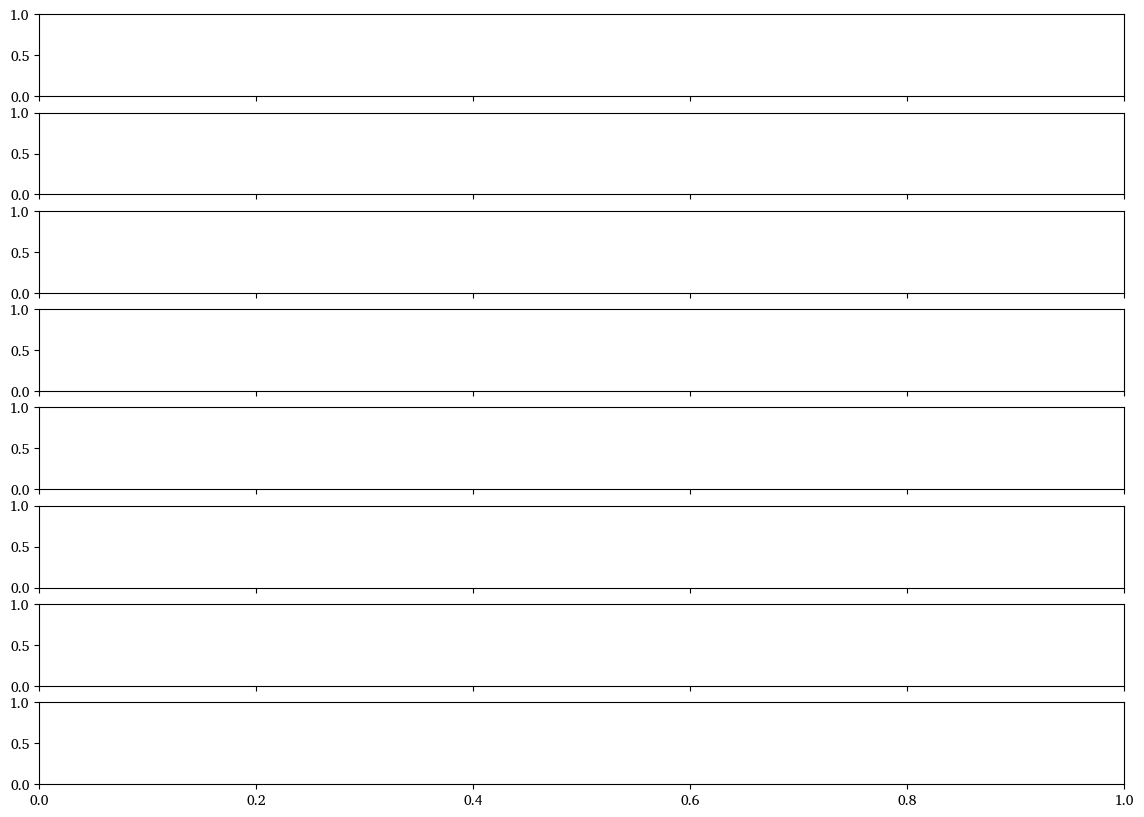

In [31]:
fig, axes = plt.subplots(8, 1, figsize=(14, 10), sharex=True)

for row_idx, (dataset_name, ax, title) in enumerate(
        zip(datasets_to_plot, axes, dataset_titles)):
    
    pivot_ds = pivots[dataset_name]
    ph_available = [p for p in ordered_phonemes_common if p in pivot_ds.index]
    
    # Build raw matrix
    matrix = np.zeros((len(sys_keys), len(ph_available)))
    for i, sys in enumerate(sys_keys):
        for j, ph in enumerate(ph_available):
            if sys in pivot_ds.columns and ph in pivot_ds.index:
                val = pivot_ds.loc[ph, sys]
                matrix[i, j] = np.nan if np.isnan(val) else min(val, 150)
            else:
                matrix[i, j] = np.nan
    
    # Normalize per dataset — divide by max value in this dataset
    dataset_max = np.nanmax(matrix)
    dataset_min = np.nanmin(matrix)
    matrix_norm = (matrix - dataset_min) / (dataset_max - dataset_min)
    
    im = ax.imshow(matrix_norm, aspect="auto", cmap="RdYlGn_r",
                   vmin=0, vmax=1, interpolation="none")
    
    # Annotate with actual values
    for i in range(len(sys_keys)):
        for j in range(len(ph_available)):
            if not np.isnan(matrix[i, j]):
                ax.text(j, i, f"{matrix[i,j]:.0f}",
                        ha="center", va="center",
                        fontsize=4.5, color="black")
    
    # Category separators
    for yb in category_boundaries_common:
        ax.axvline(x=yb, color="white", linewidth=1.5)
    
    ax.set_yticks(range(len(sys_keys)))
    ax.set_yticklabels(sys_labels_short, fontsize=7)
    ax.set_title(title, fontsize=8, fontweight="bold", loc="left", pad=2)
    
    if row_idx == len(datasets_to_plot) - 1:
        ax.set_xticks(range(len(ph_available)))
        ax.set_xticklabels(ph_available, fontsize=8,
                           fontfamily="Charis SIL", rotation=0)
        for cat, xc in category_label_pos_common.items():
            ax.text(xc, len(sys_keys) + 0.8, cat,
                    fontsize=7, ha="center", va="bottom",
                    color="gray", style="italic",
                    transform=ax.get_xaxis_transform(), clip_on=False)
    else:
        ax.set_xticks([])

# Single colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Normalized BE (0=best, 1=worst)", fontsize=8)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["Best", "Mid", "Worst"])
cbar.ax.tick_params(labelsize=7)

plt.subplots_adjust(hspace=0.4, right=0.9)
plt.savefig("phoneme_heatmap_normalized.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
def compute_phoneme_recognition(store, system_name, dataset_name, style_filter=None):
    """
    For each ref phoneme, record whether it was:
    - correctly recognized (match)
    - substituted (replaced by another phoneme)
    - deleted (missing in hyp)
    Also record what it was substituted with.
    """
    records = []
    
    for fname, data in store.items():
        if style_filter is not None:
            if data.get("style", "").lower() != style_filter.lower():
                continue
        
        # Get full alignment with edit operations
        alignment = align_sequences(data["ref_seq"], data["hyp_seq"])
        
        for ref_pos, hyp_pos in alignment:
            if ref_pos is None:
                # Insertion — hyp has extra phoneme
                continue
            
            ref_ph = data["ref_seq"][ref_pos]
            
            if hyp_pos is None:
                # Deletion
                records.append({
                    "system":     system_name,
                    "dataset":    dataset_name,
                    "phoneme":    ref_ph,
                    "operation":  "deletion",
                    "hyp_phoneme": None,
                })
            elif data["hyp_seq"][hyp_pos] == ref_ph:
                # Correct
                records.append({
                    "system":     system_name,
                    "dataset":    dataset_name,
                    "phoneme":    ref_ph,
                    "operation":  "correct",
                    "hyp_phoneme": ref_ph,
                })
            else:
                # Substitution
                records.append({
                    "system":     system_name,
                    "dataset":    dataset_name,
                    "phoneme":    ref_ph,
                    "operation":  "substitution",
                    "hyp_phoneme": data["hyp_seq"][hyp_pos],
                })
    
    return pd.DataFrame(records)

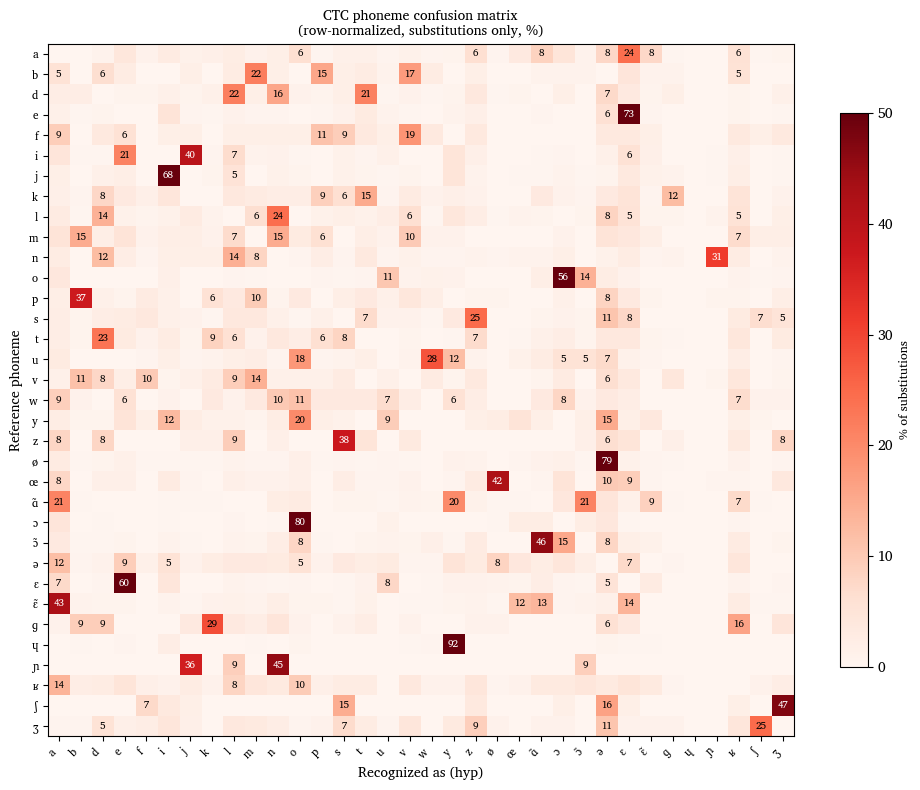

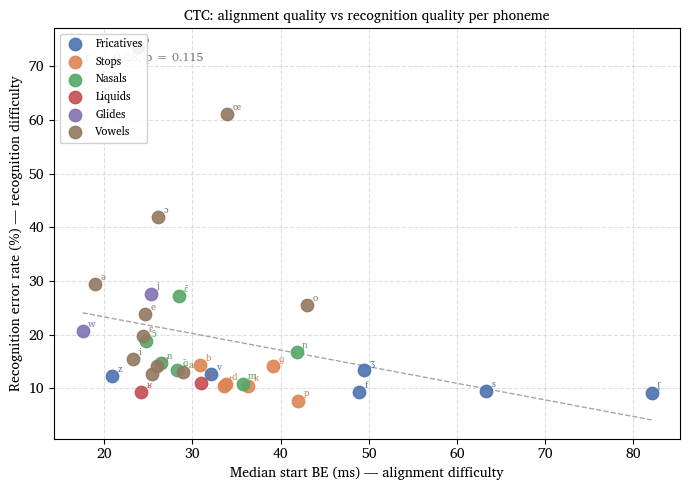


Correlation: r=-0.280, p=0.1147, n=33 phonemes

Top alignment errors (high BE, low recognition error):
   phoneme  median_be  error_rate
32       ʃ  82.051706    9.073724
13       s  63.333333    9.535791
33       ʒ  49.488372   13.315927
4        f  48.869922    9.323116
11       o  43.038932   25.414170

Top recognition errors (high error rate, low BE):
   phoneme  median_be  error_rate
20       ø  23.855739   73.571706
22       œ  33.876715   61.054767
24       ɔ  26.114426   41.919386
26       ə  18.941229   29.439655
6        j  25.327160   27.617261


In [18]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ── 1. CONFUSION MATRIX ──────────────────────────────────────────────────────

subs = df_rec[(df_rec["system"] == "CTC") & (df_rec["operation"] == "substitution")]

# Keep only phonemes with enough substitutions
min_subs = 30
top_ref = subs["phoneme"].value_counts()
top_ref = top_ref[top_ref >= min_subs].index.tolist()
top_hyp = subs["hyp_phoneme"].value_counts()
top_hyp = top_hyp[top_hyp >= min_subs].index.tolist()

# Use union of both lists
all_ph = sorted(set(top_ref) | set(top_hyp))

confusion = pd.crosstab(
    subs[subs["phoneme"].isin(all_ph)]["phoneme"],
    subs[subs["hyp_phoneme"].isin(all_ph)]["hyp_phoneme"]
)
# Reindex to have same phonemes on both axes
confusion = confusion.reindex(index=all_ph, columns=all_ph, fill_value=0)

# Normalize by row (per ref phoneme)
confusion_norm = confusion.div(confusion.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion_norm.values, cmap="Reds", vmin=0, vmax=50,
               aspect="auto")

# Annotate cells with values > 5%
for i in range(len(confusion_norm.index)):
    for j in range(len(confusion_norm.columns)):
        val = confusion_norm.values[i, j]
        if val > 5:
            ax.text(j, i, f"{val:.0f}",
                    ha="center", va="center",
                    fontsize=7,
                    color="white" if val > 30 else "black")

ax.set_xticks(range(len(confusion_norm.columns)))
ax.set_yticks(range(len(confusion_norm.index)))
ax.set_xticklabels(confusion_norm.columns, fontsize=8,
                   fontfamily="Charis SIL", rotation=45, ha="right")
ax.set_yticklabels(confusion_norm.index, fontsize=8,
                   fontfamily="Charis SIL")
ax.set_xlabel("Recognized as (hyp)", fontsize=10)
ax.set_ylabel("Reference phoneme", fontsize=10)
ax.set_title("CTC phoneme confusion matrix\n(row-normalized, substitutions only, %)",
             fontsize=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("% of substitutions", fontsize=9)

plt.tight_layout()
plt.savefig("confusion_matrix_ctc.pdf", dpi=300, bbox_inches="tight")
plt.show()


# ── 2. SCATTER: RECOGNITION ERROR vs ALIGNMENT ERROR ─────────────────────────

# Build alignment summary (median start BE per phoneme for CTC, all datasets)
align_summary = (df_ph[df_ph["system"] == "CTC"]
    .groupby("phoneme")
    .agg(median_be=("start_err", "median"),
         n_align=("start_err", "count"))
    .reset_index()
)

# Build recognition summary (error rate per phoneme for CTC, all datasets)
rec_summary = (df_rec[df_rec["system"] == "CTC"]
    .groupby("phoneme")
    .apply(lambda x: pd.Series({
        "error_rate": (x["operation"] != "correct").sum() / len(x) * 100,
        "del_rate":   (x["operation"] == "deletion").sum() / len(x) * 100,
        "sub_rate":   (x["operation"] == "substitution").sum() / len(x) * 100,
        "n_rec":      len(x)
    }))
    .reset_index()
)

# Merge
merged = pd.merge(align_summary, rec_summary, on="phoneme")
merged = merged[(merged["n_align"] >= 50) & (merged["n_rec"] >= 50)]

# Phoneme categories for coloring
phoneme_to_cat = {}
for cat, phones in categories.items():
    for ph in phones:
        phoneme_to_cat[ph] = cat

cat_colors = {
    "Fricatives": "#4C72B0",
    "Stops":      "#DD8452",
    "Nasals":     "#55A868",
    "Liquids":    "#C44E52",
    "Glides":     "#8172B2",
    "Vowels":     "#937860",
}

fig, ax = plt.subplots(figsize=(7, 5))

for cat, col in cat_colors.items():
    subset = merged[merged["phoneme"].map(phoneme_to_cat) == cat]
    ax.scatter(subset["median_be"], subset["error_rate"],
               color=col, s=80, label=cat, zorder=3, alpha=0.9)
    # Annotate each point
    for _, row in subset.iterrows():
        ax.annotate(row["phoneme"],
                    xy=(row["median_be"], row["error_rate"]),
                    xytext=(4, 3), textcoords="offset points",
                    fontsize=7, fontfamily="Charis SIL",
                    color=col)

# Add correlation line
from scipy.stats import pearsonr
r, p = pearsonr(merged["median_be"], merged["error_rate"])
x_line = np.linspace(merged["median_be"].min(), merged["median_be"].max(), 100)
m, b = np.polyfit(merged["median_be"], merged["error_rate"], 1)
ax.plot(x_line, m * x_line + b,
        color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.text(0.05, 0.92, f"r = {r:.2f}, p = {p:.3f}",
        transform=ax.transAxes, fontsize=9, color="gray")

ax.set_xlabel("Median start BE (ms) — alignment difficulty", fontsize=10)
ax.set_ylabel("Recognition error rate (%) — recognition difficulty", fontsize=10)
ax.set_title("CTC: alignment quality vs recognition quality per phoneme", fontsize=10)
ax.legend(fontsize=8, loc="upper left", framealpha=0.9)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("alignment_vs_recognition.pdf", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nCorrelation: r={r:.3f}, p={p:.4f}, n={len(merged)} phonemes")
print("\nTop alignment errors (high BE, low recognition error):")
print(merged.nlargest(5, "median_be")[["phoneme","median_be","error_rate"]])
print("\nTop recognition errors (high error rate, low BE):")
print(merged.nlargest(5, "error_rate")[["phoneme","median_be","error_rate"]])

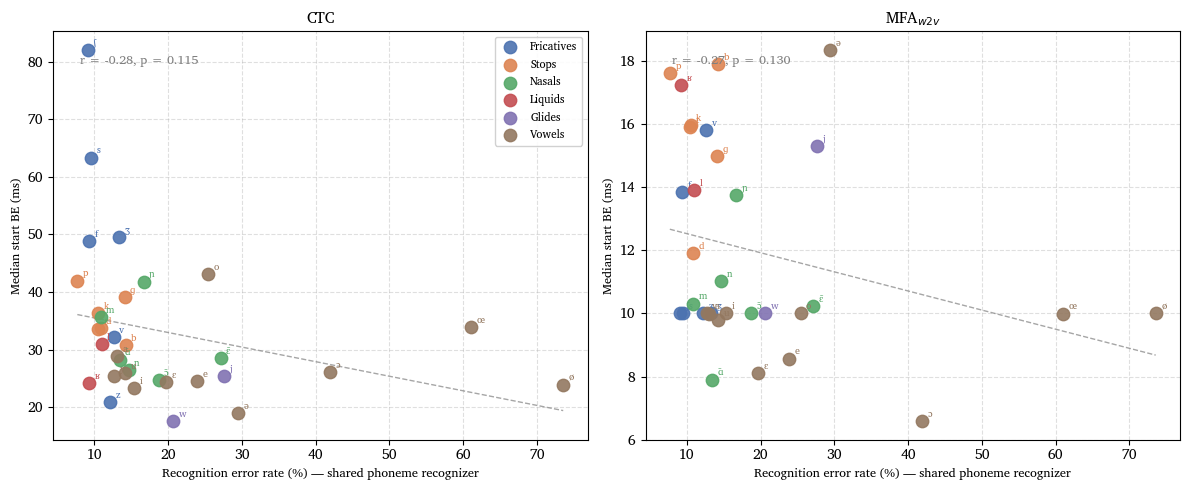

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, sys_ph, sys_label in zip(axes,
    ["CTC", "MFA_w2v"],
    ["CTC", "MFA$_{w2v}$"]):

    # Alignment BE
    align_summary = (df_ph[df_ph["system"] == sys_ph]
        .groupby("phoneme")
        .agg(median_be=("start_err", "median"),
             n_align=("start_err", "count"))
        .reset_index()
    )

    # Recognition error — always from CTC since MFA_w2v shares same transcript
    rec_summary = (df_rec[df_rec["system"] == "CTC"]
        .groupby("phoneme")
        .apply(lambda x: pd.Series({
            "error_rate": (x["operation"] != "correct").sum() / len(x) * 100,
            "n_rec": len(x)
        }))
        .reset_index()
    )

    merged = pd.merge(align_summary, rec_summary, on="phoneme")
    merged = merged[(merged["n_align"] >= 50) & (merged["n_rec"] >= 50)]
    merged["category"] = merged["phoneme"].map(phoneme_to_cat)

    for cat, col in cat_colors.items():
        subset = merged[merged["category"] == cat]
        ax.scatter(subset["error_rate"], subset["median_be"],
                   color=col, s=80, label=cat, zorder=3, alpha=0.9)
        for _, row in subset.iterrows():
            ax.annotate(row["phoneme"],
                        xy=(row["error_rate"], row["median_be"]),
                        xytext=(4, 3), textcoords="offset points",
                        fontsize=7, fontfamily="Charis SIL", color=col)

    # Correlation
    from scipy.stats import pearsonr
    r, p = pearsonr(merged["error_rate"], merged["median_be"])
    m, b = np.polyfit(merged["error_rate"], merged["median_be"], 1)
    x_line = np.linspace(merged["error_rate"].min(),
                         merged["error_rate"].max(), 100)
    ax.plot(x_line, m * x_line + b,
            color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(0.05, 0.92, f"r = {r:.2f}, p = {p:.3f}",
            transform=ax.transAxes, fontsize=9, color="gray")

    ax.set_xlabel("Recognition error rate (%) — shared phoneme recognizer",
                  fontsize=9)
    ax.set_ylabel("Median start BE (ms)", fontsize=9)
    ax.set_title(sys_label, fontsize=11)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    if ax == axes[0]:
        ax.legend(fontsize=8, loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.savefig("alignment_vs_recognition_ctc_mfa.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# Rebuild df_ph using only Typaloc
typaloc_datasets = ["Typaloc_Ctrl", "Typaloc_Park", "Typaloc_Cereb", "Typaloc_Sla"]

# Filter df_ph
df_ph_typaloc = df_ph[df_ph["dataset"].isin(typaloc_datasets)]

# Compute global pivot over all Typaloc data combined
summary_typaloc = (df_ph_typaloc
    .groupby(["system", "phoneme"])
    .agg(median_be=("start_err", "median"),
         n=("start_err", "count"))
    .reset_index()
)
summary_typaloc = summary_typaloc[summary_typaloc["n"] >= 30]
pivot_typaloc = summary_typaloc.pivot(
    index="phoneme", columns="system", values="median_be")
pivot_typaloc = pivot_typaloc.dropna()

print(f"Typaloc phonemes: {len(pivot_typaloc)}")
print(pivot_typaloc.sort_values("CTC", ascending=False).to_string())

Typaloc phonemes: 31
system         CTC  MFA_asrw2v   MFA_gold  MFA_goldphone    MFA_w2v
phoneme                                                            
ʃ        92.008457   10.891616  12.456536      10.695179  10.891616
f        87.630382   13.634794  16.865532      13.344588  12.522917
s        86.944382   10.001000  10.531561      10.000000  10.001000
b        75.473622   16.795007  17.569847      10.000000  17.330660
k        75.174091   13.596184  15.787690      11.717901  14.410731
p        74.624977   11.108751  11.831174      11.029090  11.352761
t        68.311734   19.999000  22.336376      20.000000  20.000000
ɡ        64.236453   10.000500  10.001000      10.002000  10.001000
m        62.518112   10.112034  10.811336      10.000000  10.000000
d        58.285714   10.002000  10.002000      10.000000  10.000000
ʒ        52.173907   10.277682  10.937524      10.451207  10.001000
n        48.913156   15.917112  15.617333      10.396349  13.423051
v        47.090909   11.834

In [36]:
import pickle

with open("ctc_results/alignment_rhap.pkl", "rb") as f:
    store = pickle.load(f)

# Check actual style values
styles = set(data.get("style", "?") for data in store.values())
print("Styles in store:", styles)

# Check a few files
for fname, data in list(store.items())[:5]:
    print(f"{fname}: style='{data.get('style', '?')}'")

Styles in store: {'semi', 'spont', 'planned'}
Rhap-D0020.wav: style='spont'
Rhap-D2002.wav: style='planned'
Rhap-M0009.wav: style='spont'
Rhap-D0017.wav: style='spont'
Rhap-D2006.wav: style='planned'


NameError: name 'systems_plot' is not defined

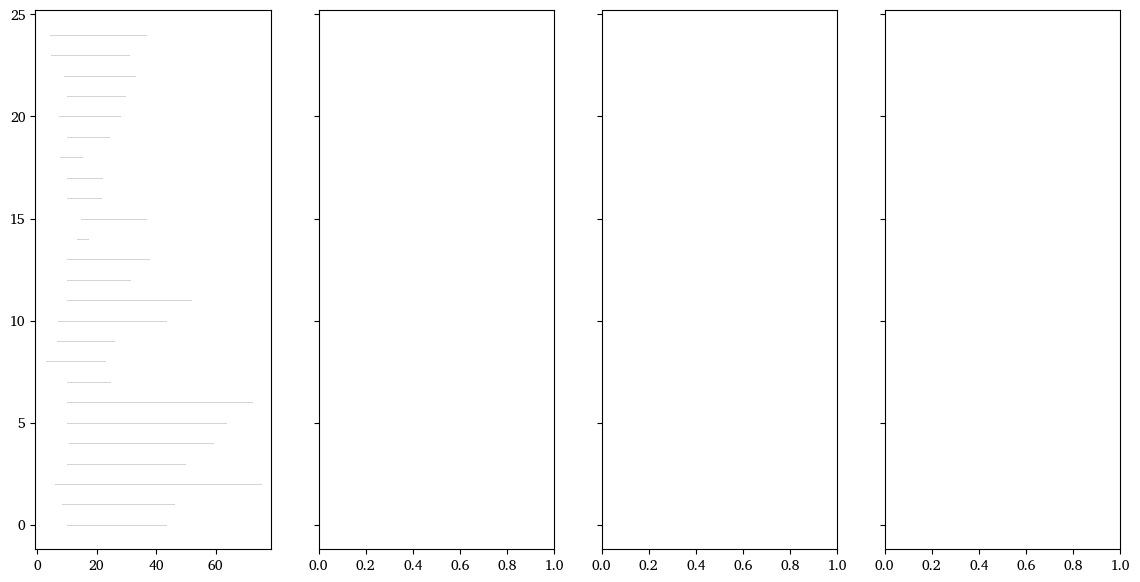

In [21]:
datasets_to_plot = ["Typaloc_Ctrl", "Typaloc_Park", "Typaloc_Cereb", "Typaloc_Sla"]
dataset_titles   = ["Typaloc\nCtrl", "Typaloc\nPark", "Typaloc\nCereb", "Typaloc\nSla"]
#First pass: collect all phonemes and pivot per dataset
pivots = {}
ordered_per_dataset = {}

for dataset_name in datasets_to_plot:
    df_sub = df_ph[df_ph["dataset"] == dataset_name]
    summary_ds = (df_sub
        .groupby(["system", "phoneme"])
        .agg(median_be=("start_err", "median"),
             n=("start_err", "count"))
        .reset_index()
    )
    summary_ds = summary_ds[summary_ds["n"] >= 20]
    pivot_ds = summary_ds.pivot(index="phoneme", columns="system", values="median_be")
    pivot_ds = pivot_ds.dropna()
    pivots[dataset_name] = pivot_ds

# Build a COMMON phoneme order — union of all phonemes present in all datasets
common_phonemes = set(pivots[datasets_to_plot[0]].index)
for ds in datasets_to_plot[1:]:
    common_phonemes &= set(pivots[ds].index)

# Order by categories, sort within category by mean CTC across datasets
ordered_phonemes_common = []
category_boundaries_common = []
category_label_pos_common = {}
pos = 0
for cat, phones in categories.items():
    phones_in = [p for p in phones if p in common_phonemes]
    if not phones_in:
        continue
    # sort by mean CTC error across all datasets
    phones_in = sorted(phones_in, key=lambda p: np.mean([
        pivots[ds].loc[p, "CTC"] for ds in datasets_to_plot
        if p in pivots[ds].index and "CTC" in pivots[ds].columns
    ]))
    category_label_pos_common[cat] = pos + len(phones_in) / 2 - 0.5
    for ph in phones_in:
        ordered_phonemes_common.append(ph)
        pos += 1
    category_boundaries_common.append(pos - 0.5)

category_boundaries_common = category_boundaries_common[:-1]
y_common = np.arange(len(ordered_phonemes_common))

# Determine shared x-axis max
xmax = max(
    pivots[ds].loc[ph, "CTC"]
    for ds in datasets_to_plot
    for ph in ordered_phonemes_common
    if ph in pivots[ds].index and "CTC" in pivots[ds].columns
) * 1.1

# Plot grid
n_datasets = len(datasets_to_plot)
fig, axes = plt.subplots(1, 4,
                         figsize=(3.5 * 4, max(5, len(ordered_phonemes_common) * 0.28)),
                         sharey=True)

for col, (dataset_name, ax, title) in enumerate(zip(datasets_to_plot, axes, dataset_titles)):
    pivot_ds = pivots[dataset_name]

    # Only plot phonemes present in this dataset
    ph_available = [p for p in ordered_phonemes_common if p in pivot_ds.index]
    y_available  = [y_common[ordered_phonemes_common.index(p)] for p in ph_available]
    pivot_sub    = pivot_ds.loc[ph_available]

    # Gray connecting line: min MFA to CTC
    mfa_cols = [c for c in ["MFA_asrw2v","MFA_gold","MFA_w2v","MFA_goldphone"]
                if c in pivot_sub.columns]
    for yi, ph in zip(y_available, ph_available):
        if "CTC" in pivot_sub.columns and mfa_cols:
            mfa_min = pivot_sub.loc[ph, mfa_cols].min()
            ctc_val = pivot_sub.loc[ph, "CTC"]
            ax.plot([mfa_min, ctc_val], [yi, yi],
                    color="lightgray", linewidth=0.7, zorder=1)

    # Plot systems
    for sys, lbl, col_c, mk, sz in zip(systems_plot, labels, colors, markers, sizes):
        if sys not in pivot_sub.columns:
            continue
        vals = [pivot_sub.loc[ph, sys] if ph in pivot_sub.index else np.nan
                for ph in ph_available]
        ax.scatter(vals, y_available,
                   color=col_c, marker=mk, s=sz,
                   label=lbl, zorder=3, alpha=0.9)

    # Category separators
    for yb in category_boundaries_common:
        ax.axhline(y=yb, color="black", linewidth=0.5,
                   linestyle="--", alpha=0.4)

    # Category labels only on last column
    if col == n_datasets - 1:
        for cat, yc in category_label_pos_common.items():
            ax.text(xmax * 1.03, yc, cat,
                    fontsize=7, va="center", ha="left",
                    color="gray", style="italic", clip_on=False)

    ax.set_xlim(0, xmax)
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("Median\nstart BE (ms)", fontsize=8)
    ax.xaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)

    # y-axis labels only on first column
    if col == 0:
        ax.set_yticks(y_common)
        ax.set_yticklabels(ordered_phonemes_common, fontsize=8,
                           fontfamily="Charis SIL")
    else:
        ax.set_yticks(y_common)
        ax.set_yticklabels([])

# Shared legend below figure
handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="lower center", ncol=5,
           fontsize=8, framealpha=0.9, edgecolor="gray",
           bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig("phoneme_errors_all_datasets.pdf", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'pivots_typaloc' is not defined

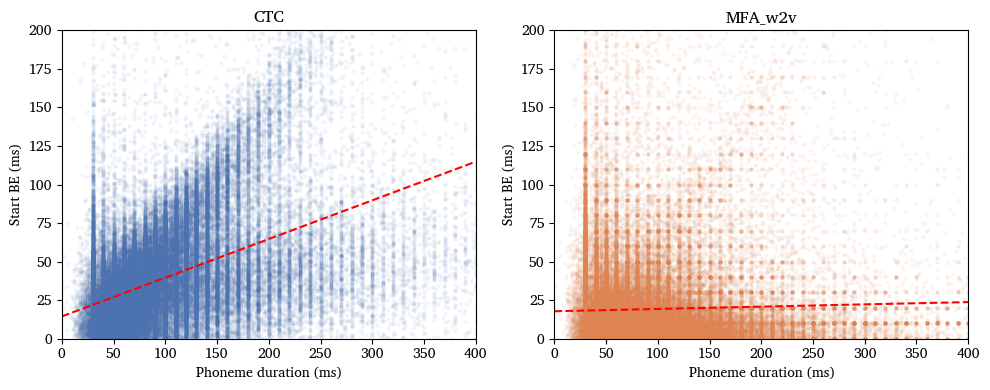

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, sys in zip(axes, ["CTC", "MFA_w2v"]):
    subset = df_ph[df_ph["system"] == sys]
    ax.scatter(subset["duration"], subset["start_err"],
               alpha=0.05, s=5, color="#4C72B0" if sys=="CTC" else "#DD8452")
    ax.set_xlabel("Phoneme duration (ms)")
    ax.set_ylabel("Start BE (ms)")
    ax.set_title(sys)
    ax.set_xlim(0, 400)
    ax.set_ylim(0, 200)
    
    # Add trend line
    from numpy.polynomial import polynomial as P
    x = subset["duration"].values
    y = subset["start_err"].values
    mask = (x < 400) & (y < 200)
    coeffs = np.polyfit(x[mask], y[mask], 1)
    xline = np.linspace(0, 400, 100)
    ax.plot(xline, np.polyval(coeffs, xline), 
            color="red", linewidth=1.5, linestyle="--")

plt.tight_layout()
plt.savefig("duration_vs_be.pdf", dpi=300, bbox_inches="tight")

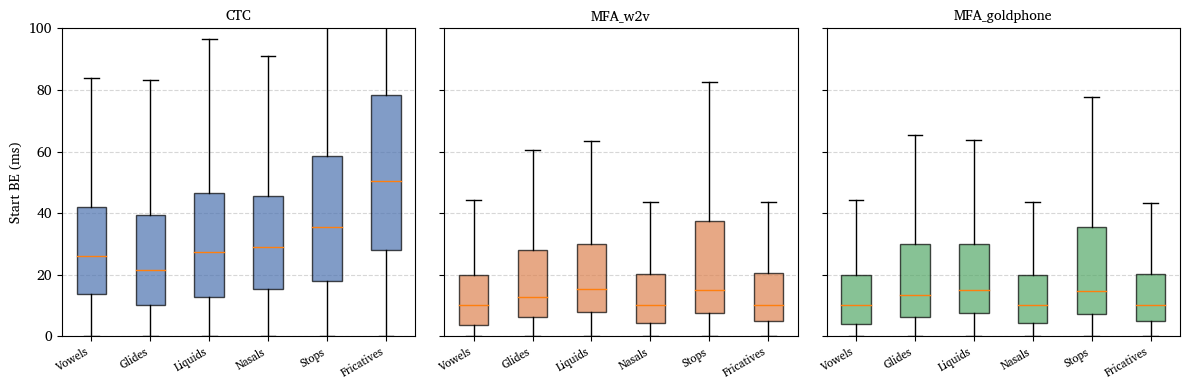

In [22]:
import matplotlib.pyplot as plt

# Map each phoneme to its category
phoneme_to_cat = {}
for cat, phones in categories.items():
    for ph in phones:
        phoneme_to_cat[ph] = cat

df_ph["category"] = df_ph["phoneme"].map(phoneme_to_cat)
df_ph_clean = df_ph.dropna(subset=["category"])

cat_order = ["Vowels", "Glides", "Liquids", "Nasals", "Stops", "Fricatives"]
systems_3 = ["CTC", "MFA_w2v", "MFA_goldphone"]
colors_3  = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, sys, col in zip(axes, systems_3, colors_3):
    data_by_cat = [
        df_ph_clean[(df_ph_clean["system"]==sys) & 
                    (df_ph_clean["category"]==cat)]["start_err"].values
        for cat in cat_order
    ]
    bp = ax.boxplot(data_by_cat, vert=True, patch_artist=True,
                    labels=cat_order, showfliers=False)
    for patch in bp["boxes"]:
        patch.set_facecolor(col)
        patch.set_alpha(0.7)
    ax.set_title(sys, fontsize=10)
    ax.set_xticklabels(cat_order, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Start BE (ms)" if ax == axes[0] else "")
    ax.set_ylim(0, 100)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("category_boxplot.pdf", dpi=300, bbox_inches="tight")

NameError: name 'df_all' is not defined

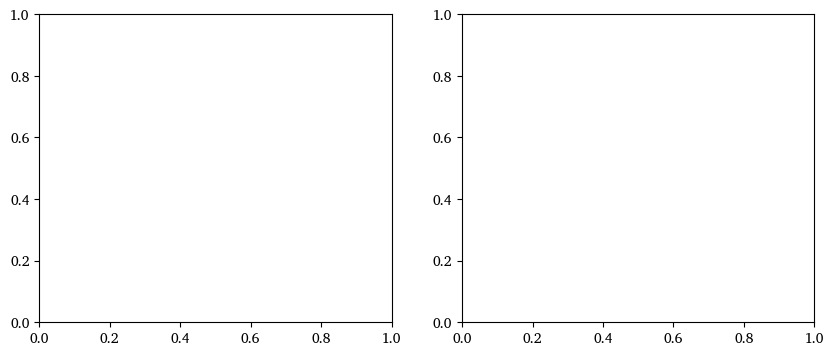

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

dataset_colors = {"Rhapsodie": "#4C72B0", "Typaloc": "#DD8452", "Tapas": "#55A868"}

for ax, sys_key, sys_label in zip(axes, 
    ["ctc_results", "mfa_results_w2vmfa"], ["CTC", "MFA$_{w2v}$"]):
    
    subset = df_all[df_all["system"] == sys_key]
    for ds, col in dataset_colors.items():
        rows = subset[subset["dataset"] == ds]
        ax.scatter(rows["PER (%)"], rows["Median_start_error (ms)"],
                   color=col, s=60, label=ds, alpha=0.8, zorder=3)
    
    ax.set_xlabel("PER (%)", fontsize=10)
    ax.set_ylabel("Median start BE (ms)", fontsize=10)
    ax.set_title(sys_label, fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("per_vs_be_scatter.pdf", dpi=300, bbox_inches="tight")

In [65]:
"""from jiwer import process_words
from collections import defaultdict
style = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")
style_stats = defaultdict(lambda: {
    "S": 0,
    "D": 0,
    "I": 0,
    "N": 0,
    "TP_20":0,
    "FP_20":0,
    "FN_20":0,
    "midpoint_errors":[],
    "boundary_errors": []
})
audio_dir = "/vol/corpora/Rhapsodie/wav16k_corrected"
textgrid_dir = Path("/vol/corpora/Rhapsodie/TextGrids-fev2013/")

style = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")
ref_files = textgrid_dir.glob("*") 

all_pairs = []
ref_inventory=set()
pred_inventory=set()
total_edits = 0
all_predicted_segments = []
total_ref_tokens = 0
all_boundary_errors=[]
total_filtered = 0
total_S = total_D = total_I = total_N = 0
for filepath in ref_files:
    f = filepath.stem[:-4]+".wav"
    audio_path = os.path.join(audio_dir,f )
    s = list(style[style["file"]==f.split("-")[1].split(".")[0]]["style"])[0]
    if "D0001" not in audio_path and "M2006" not in audio_path and "D1003" not in audio_path: 
                    
        textgrid_path = os.path.join(textgrid_dir,f.replace(".wav", "-Pro.TextGrid"))
        
        pred_phonemes, pred_alignments = get_phoneme_alignments(model, processor, audio_path)
        ref_alignments = get_reference_alignments(textgrid_path,t="phone")
        
        clean_hyp = clean_alignment_dict(pred_alignments,is_hyp=True)
        clean_ref = clean_alignment_dict(ref_alignments,flag="",is_hyp=False)
        
        ref_offset = clean_ref[0]["start"]
        hyp_offset = clean_hyp[0]["start"]
        #ref_intervals=clean_ref
        #hyp_intervals=clean_hyp
        ref_intervals = [{
            "phoneme": item["phoneme"],
            "start": item["start"] - ref_offset,
            "end": item["end"] - ref_offset} for item in clean_ref]
        ref_midpoints = [(seg["start"] + seg["end"]) / 2 for seg in ref_intervals]
        hyp_intervals = [{
            "phoneme": item["phoneme"],
            "start": item["start"] 
            ,
            "end": item["end"] - hyp_offset} for item in clean_hyp]
        pred_midpoints = [  (seg["start"] + seg["end"]) / 2 for seg in hyp_intervals]
        TP, FP, FN = compute_f1_20(ref_midpoints, pred_midpoints)

        
        
        audio_id = f
        style_label = s
        
        for seg in hyp_intervals:
            all_predicted_segments.append({
                "audio_id": audio_id,
                "style": style_label,
                "phoneme": seg["phoneme"],
                "start": seg["start"],
                "end": seg["end"],
                "duration": seg["end"] - seg["start"],

            })
        # Normalize
        ref_seq = extract_phoneme_sequence(clean_ref)
        hyp_seq = extract_phoneme_sequence(clean_hyp)

        pred_inventory.update(hyp_seq)
    
        ref_inventory.update(ref_seq)
        print(ref_inventory - pred_inventory)
        print("--")
        print(pred_inventory - ref_inventory)
        all_pairs.append((ref_seq,hyp_seq))
        out = process_words(" ".join(ref_seq), " ".join(hyp_seq))
        
        
        style_stats[s]["S"] += out.substitutions
        style_stats[s]["D"] += out.deletions
        style_stats[s]["I"] += out.insertions
        style_stats[s]["N"] += len(ref_seq)
        
        start_err, end_err, dur_err, mid_err, matched_pairs, n_filtered = \
            match_alignments_lev(ref_intervals, hyp_intervals, ref_seq, hyp_seq)
        total_filtered += n_filtered        
        style_stats[s]["midpoint_errors"].extend(mid_err)
        style_stats[s]["TP_20"] += TP
        style_stats[s]["FP_20"] += FP
        style_stats[s]["FN_20"] += FN
        #all_boundary_errors.extend(start_err)
        style_stats[s]["boundary_errors"].extend(start_err)
    """

'from jiwer import process_words\nfrom collections import defaultdict\nstyle = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")\nstyle_stats = defaultdict(lambda: {\n    "S": 0,\n    "D": 0,\n    "I": 0,\n    "N": 0,\n    "TP_20":0,\n    "FP_20":0,\n    "FN_20":0,\n    "midpoint_errors":[],\n    "boundary_errors": []\n})\naudio_dir = "/vol/corpora/Rhapsodie/wav16k_corrected"\ntextgrid_dir = Path("/vol/corpora/Rhapsodie/TextGrids-fev2013/")\n\nstyle = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")\nref_files = textgrid_dir.glob("*") \n\nall_pairs = []\nref_inventory=set()\npred_inventory=set()\ntotal_edits = 0\nall_predicted_segments = []\ntotal_ref_tokens = 0\nall_boundary_errors=[]\ntotal_filtered = 0\ntotal_S = total_D = total_I = total_N = 0\nfor filepath in ref_files:\n    f = filepath.stem[:-4]+".wav"\n    audio_path = os.path.join(audio_dir,f )\n    s = list(style[style["file"]==f.split("-")[1].split(".")[0]]["style"])[0]\n    if "D0001" not in audio_path and "M2006" not 

In [124]:
import pandas as pd

df_pred = pd.DataFrame(all_predicted_segments)
#df_pred.to_csv("all_predicted_alignments_rhap.csv", index=False)
df_style=pd.DataFrame(style_stats)
df_style.to_csv("stats_rhap_50ms.csv")

In [20]:
results = []

for style, stats in style_stats.items():
    S = stats["S"]
    D = stats["D"]
    I = stats["I"]
    N = stats["N"]

    # --- PER ---
    per = (S + D + I) / N if N > 0 else 0

    # --- Midpoint Boundary Errors ---
    errors = np.array(stats["midpoint_errors"])

    if len(errors) > 0:
        mean_err = np.mean(errors)
        median_err = np.median(errors)
        max_err = np.max(errors)

        within_20ms = np.mean(errors <= 0.02) * 100
        within_50ms = np.mean(errors <= 0.05) * 100
    else:
        mean_err = median_err = max_err = 0
        within_20ms = within_50ms = 0

    # --- F1@20ms ---
    TP = stats.get("TP_20", 0)
    FP = stats.get("FP_20", 0)
    FN = stats.get("FN_20", 0)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

    if precision + recall > 0:
        f1_20 = 2 * precision * recall / (precision + recall)
    else:
        f1_20 = 0

    results.append({
        "style": style,
        "PER (%)": per * 100,
        "Substitutions": S,
        "Deletions": D,
        "Insertions": I,
        "N_ref": N,
        "Mean_midpoint_error (ms)": mean_err * 1000,
        "Median_midpoint_error (ms)": median_err * 1000,
        "Max_midpoint_error (ms)": max_err * 1000,
        "% within 20ms": within_20ms,
        "% within 50ms": within_50ms,
        "F1@50ms": f1_20 * 100
    })

results_df = pd.DataFrame(results)
results_df

,style,PER (%),Substitutions,Deletions,Insertions,N_ref,Mean_midpoint_error (ms),Median_midpoint_error (ms),Max_midpoint_error (ms),% within 20ms,% within 50ms,F1@50ms
0,spont,21.054244,3294,6105,910,48964,195.089512,31.009594,53563.094939,36.838114,61.923417,80.758737
1,planned,11.811589,1367,1675,411,29234,76.609938,42.130499,5536.340391,29.608277,55.093158,83.315852
2,semi,21.126761,845,1892,368,14697,375.591908,132.914447,10293.331307,1.387960,8.269231,72.278436


In [21]:
results_df.to_csv("results_rhap.csv")

In [127]:
# Check average file duration per style
from jiwer import process_words
from collections import defaultdict
style = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")
style_stats = defaultdict(lambda: {
    "S": 0,
    "D": 0,
    "I": 0,
    "N": 0,
    "TP_20":0,
    "FP_20":0,
    "FN_20":0,
    "midpoint_errors":[],
    "boundary_errors": []
})
audio_dir = "/vol/corpora/Rhapsodie/wav16k_corrected"
textgrid_dir = Path("/vol/corpora/Rhapsodie/TextGrids-fev2013/")

style = pd.read_csv("/vol/corpora/Rhapsodie/wav_style.csv")
 
for style_name in ["planned", "spont", "semi"]:
    durations = []
    ref_files = textgrid_dir.glob("*")
    for filepath in ref_files:
        f = filepath.stem[:-4] + ".wav"
        
        if "D0001" in f or "M2006" in f or "D1003" in f:
            continue
        s = list(style[style["file"] == f.split("-")[1].split(".")[0]]["style"])[0]
        
        if s == style_name:
           
            audio_path = os.path.join(audio_dir, f)
            try:
                audio, sr = sf.read(audio_path)
                durations.append(len(audio) / sr)
            except Exception as e:
                print(f"Skipping {f}: {e}")
                continue
    if durations:
        print(f"{style_name}: mean={np.mean(durations):.1f}s, max={np.max(durations):.1f}s, n={len(durations)}")
    else:
        print(f"{style_name}: no files found — check style label values with style['style'].unique()")

planned: mean=308.0s, max=627.7s, n=11
spont: mean=127.3s, max=499.4s, n=39
semi: mean=370.3s, max=531.6s, n=4


In [110]:
style['style'].unique()

array(['planned', 'semi', 'spont'], dtype=object)

In [129]:
results = []

for style, stats in style_stats.items():
    S = stats["S"]
    D = stats["D"]
    I = stats["I"]
    N = stats["N"]

    # --- PER ---
    per = (S + D + I) / N if N > 0 else 0

    # --- Midpoint Boundary Errors ---
    errors = np.array(stats["midpoint_errors"])

    if len(errors) > 0:
        mean_err = np.mean(errors)
        median_err = np.median(errors)
        max_err = np.max(errors)

        within_20ms = np.mean(errors <= 0.02) * 100
        within_50ms = np.mean(errors <= 0.05) * 100
    else:
        mean_err = median_err = max_err = 0
        within_20ms = within_50ms = 0

    # --- F1@20ms ---
    TP = stats.get("TP_20", 0)
    FP = stats.get("FP_20", 0)
    FN = stats.get("FN_20", 0)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0

    if precision + recall > 0:
        f1_20 = 2 * precision * recall / (precision + recall)
    else:
        f1_20 = 0

    results.append({
        "style": style,
        "PER (%)": per * 100,
        "Substitutions": S,
        "Deletions": D,
        "Insertions": I,
        "N_ref": N,
        "Mean_midpoint_error (ms)": mean_err * 1000,
        "Median_midpoint_error (ms)": median_err * 1000,
        "Max_midpoint_error (ms)": max_err * 1000,
        "% within 20ms": within_20ms,
        "% within 50ms": within_50ms,
        "F1@20ms": f1_20 * 100
    })

results_df = pd.DataFrame(results)
results_df

""
